# Rectified Image Processing for Thermal Landscapes Project
### Letaba
 PB 6/23/22
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

##### Weird Things about Letaba
- The shapefile has 3 columns for treatments: 
    - "Exclosure" which is either "Full"/"Partial"/"Open"
    - "TopoPositi" which is either "Upland"/"Lowland"
    - "Treatment" which is either "Inside"/"Outside"

In [2]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns
from scipy.stats import ks_2samp
import time

# # # USER INPUTS
img_dir = Path('/n/holystore01/LABS/davies_lab/Lab/data/products/2020_10-12/December_campaign/Letaba_EP/raster/ortho/Thermal/rect')
shp_f = Path('./data/in/Polygons_AD_current/Letaba_polygon.shp')

# Set site/project string for output figures and stats
projstr = 'Letaba'

# Set threshold of overlap tolerance btwn images
# threshold = 0.25
# 7/29 - run to get stats about overlapping images
threshold = 0.25

# Set hue order for plotting
exclosure_hues = ["Open", "Partial", "Full"]
topo_hues = ["Upland", "Lowland"]

# # # END USER INPUTS

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# NOTE: The below is discontinued as of 6/22/2022 -
# instead the code goes through all images that overlap multiple treatments
# And removes images based on the above overlap threshold
# Set number of images to consider for final image list 
# nimgs = 1000

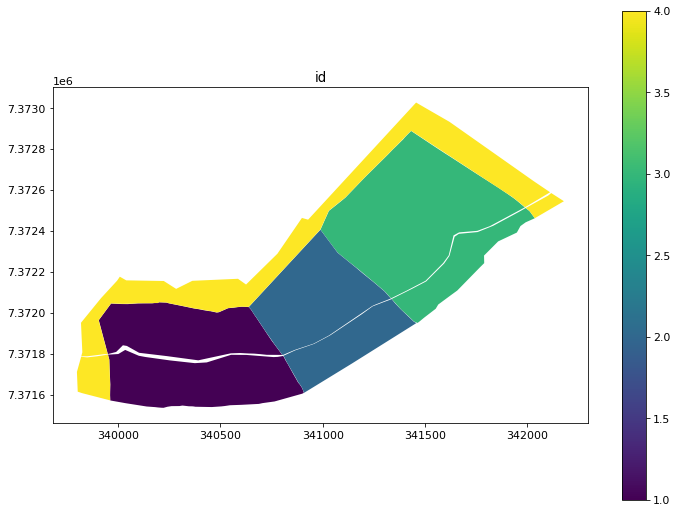

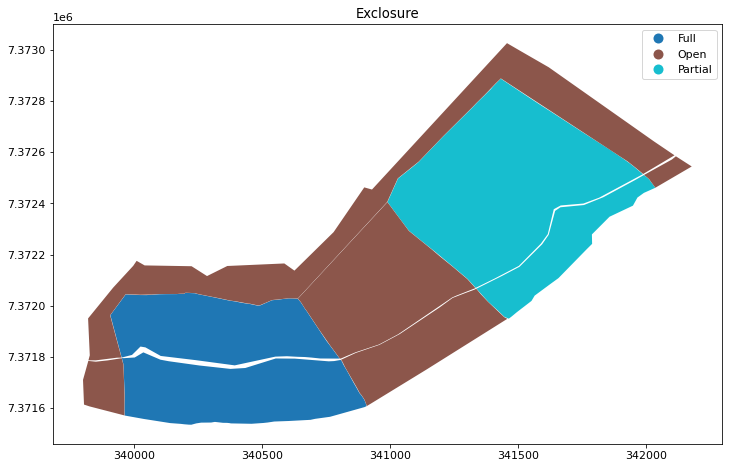

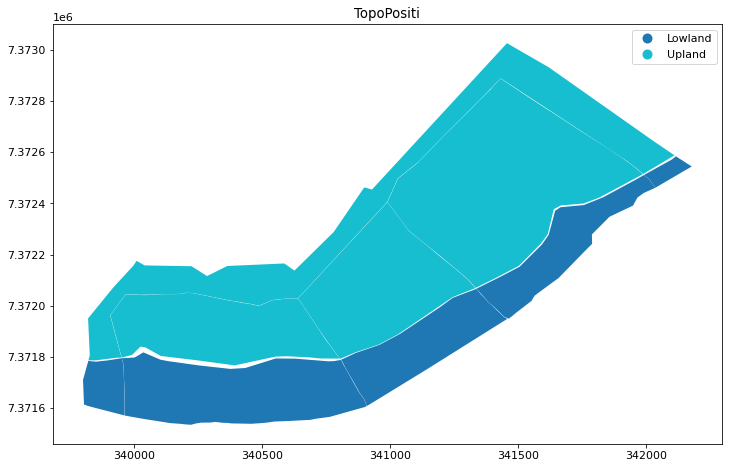

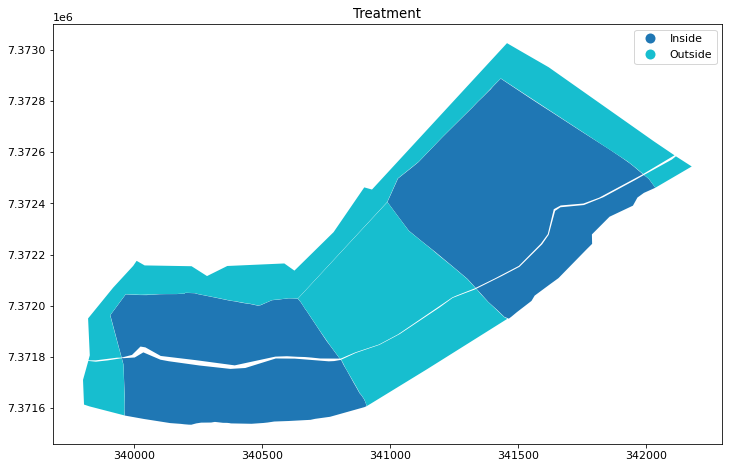

In [3]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    shp.plot(column=c, legend=True)
    plt.title(c)
    plt.savefig(f'./figs/ShapefileFeatures_{c}_{projstr}.png', dpi=300)

In [4]:
# Define a simple evenness function
# compares the difference in coverage 
def evenness(x):
    # Filter for non-zero values
    X = x.loc[x>=0.01]
    # if more than 2:
    if len(X)>=2:
        # test difference between the values
        # This is the mean difference between the values
        # Divided by the sum of the values
        # 1 - is to make it an descending scale (higher values are better)
        # even = 1 - (np.mean(np.abs(np.diff((X)))) / np.sum(X))
        
        # Actually, screw that! Use coeff. of variation
         # NOTE: -1* need to rescale so scale is descending
        even = -1*(np.std(X)/np.mean(X))
    else:
        even = np.nan
    return even

In [4]:
# Load and plot a single image
# img = rioxr.open_rasterio(f,
#                           parse_coordinates=True,
#                           masked=True)
# img.sel(band=4).plot()

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [5]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    
    # warnings.simplefilter("ignore")
    warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, T, feat in zip(shp.index, shp.Exclosure, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        img_gdf[f'Area {T} {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {T} {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in descending order of evenness, then summed percent overlap
    img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

<AxesSubplot:>

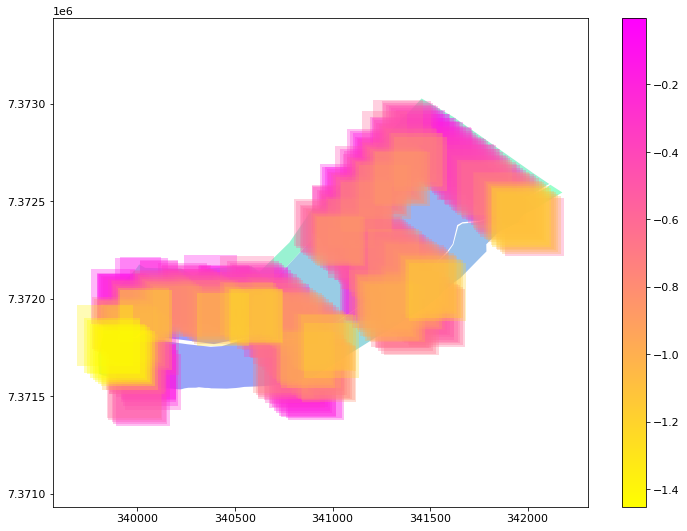

In [6]:
# Keep only the images that overlap multiple treatments
# Cutoff is that img has to overlap at least 100 m2 
# img_gdf['OverlapsTreatments'] = img_gdf.filter(like='Area').apply(lambda x: np.sum(x>100) > 1, axis=1)
# img_gdf_filter = img_gdf.loc[img_gdf['OverlapsTreatments']]

# Keep only the images that overlap multiple treatments
# (Cutoff is that img has to overlap at least 2000 m2)
# Note: This cutoff can be tuned to each site.
# In some cases, you may want less images. In others, more.
# Edited 7/5/2022 to only count images that overlap both inside and outside,
# Discluding images that overlap 2 polygons, but both polygons are labelled as the same treatment.
areathres = 3000
img_gdf['OverlapsFull'] = img_gdf.filter(like='Area Full').apply(lambda x: np.sum(x>=areathres) > 0, axis=1)
img_gdf['OverlapsPartial'] = img_gdf.filter(like='Area Partial').apply(lambda x: np.sum(x>=areathres) > 0, axis=1)
img_gdf['OverlapsOpen'] = img_gdf.filter(like='Area Open').apply(lambda x: np.sum(x>=areathres) > 0, axis=1)

idx = ((img_gdf['OverlapsFull'] & img_gdf['OverlapsPartial']) |
       (img_gdf['OverlapsFull'] & img_gdf['OverlapsOpen']) |
       (img_gdf['OverlapsPartial'] & img_gdf['OverlapsOpen']))
            
img_gdf_filter = img_gdf.loc[idx]

# Save the cream of the crop in a new df - DISCONTINUED 6/22/2022
# nimgs = len(img_gdf)
# img_gdf_filter = img_gdf.loc[0:(nimgs-1)]

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)
ax.axis('equal')
shp.plot(ax=ax, cmap='winter', alpha=0.4)
img_gdf_filter.plot(ax=ax, alpha=0.3, cmap='spring_r', column='Evenness', legend=True)

### Step 2 - Choose a random set of images that do not overlap with each other

In [7]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
              'pixels_xr':{}.fromkeys(shp.index, []),
              'Exclosure':{}.fromkeys(shp.index, []),
              'Topo':{}.fromkeys(shp.index, []),
              'Polygon':{}.fromkeys(shp.index, [])}

img_dict = {'imgf':[], 'boundary_poly':[],
            'overlappixels_xr':{}.fromkeys(shp.index, [])}

# Discontinued
# Shuffle the images so you img_gdf_maxareaa different one each time
# https://stackoverflow.com/questions/29576430/shuffle-dataframe-rows
# img_gdf_shuffle = img_gdf_filter.sample(frac=1).reset_index(drop=True)
# img_gdf_shuffle = img_gdf_filter.copy()

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_filter.img.values, img_gdf_filter.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)
        
        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)
        
        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Make a geodataframe to use below
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):
            
            img_dict['imgf'].append(str(i).split('/')[-1])   
            # Save the shapely polygon
            img_dict['boundary_poly'].append(g)
            
            # TBD: Could use this here (or seperately) to save overlap zones with other images
            # Then run a KS test between images in those zones to check their similarity
            # Store the pixels that overlap with other images
            # img_dict['overlappixels_xr'][ID].append(pixels)

            # loop through features in shapefile
            for ID, feat in zip(shp.index, shp.geometry.values):
                
                # Save attributes from images and shapefiles in nested dict
                pixel_dict['imgf'][ID].append(str(i).split('/')[-1])
                pixel_dict['Exclosure'][ID].append(shp.loc[ID].Exclosure)
                pixel_dict['Topo'][ID].append(shp.loc[ID].TopoPositi)
                pixel_dict['Polygon'][ID].append(feat)

                # Get the intersection, and clip your raster with it
                if clipbox.intersects(feat)[0]:
                    pixels = img_k.rio.clip(clipbox.intersection(feat), drop=True)     
                    # Also store number of non-na pixels in each
                    # n = np.sum(np.isnan(pixels.data.flatten()))
                else:
                    pixels=[]
                    n=0
                    
                # Store it in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)
                # img_dict['pixels_xr'][ID].append(pixels)

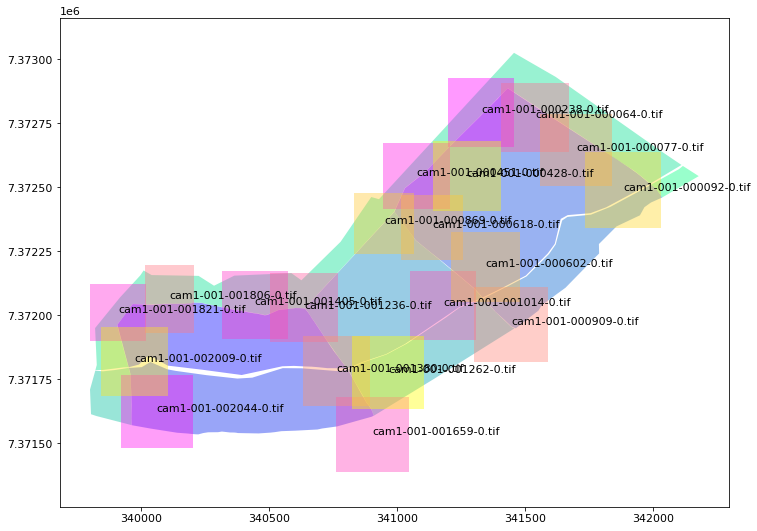

In [8]:
# Plot when done to get a sense of images and locations
poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], 
                        index=img_dict['imgf'],
                        crs='EPSG:32736')

fig, ax = plt.subplots()

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s) for s in np.array(img_dict['imgf'])]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)
    
# Note: disabled figure saving below for image overlap analysis (threshold = 0.8)
fig.savefig(f'./figs/FinalImageOverlap_{projstr}.png', dpi=300)

In [9]:
# Initialize df list for loop
df_list = []

# For each polygon treatment in the shapefile
for ID in shp.index:
    
    # For each image
    for i, img in enumerate(pixel_dict['imgf'][ID]):
        
        df = pd.DataFrame()
        
        # If there are pixels for this treatment (it's NOT an empty list)
        if len(pixel_dict['pixels_xr'][ID][i])!=0:
            
            # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
                               'Exclosure':pixel_dict['Exclosure'][ID][i],
                               'Topo':pixel_dict['Topo'][ID][i],
                               'imgf':img})
            
            # Drop na rows
            df.dropna(axis=0, how='any', inplace=True)
            
            # store DataFrame in list
            df_list.append(df.copy(deep=True))

# Concat all the dfs to make a full df 
df_pixels = pd.concat(df_list, ignore_index=True, sort=False)

# Special for letaba - drop the images that don't overlap 2 treatments manually
# added 7/5/22
df_pixels = df_pixels.loc[df_pixels.imgf != 'cam1-001-000428-0.tif']

## Print Statistics and Plot

In [11]:
nLow = df_pixels.Topo.loc[df_pixels.Topo=='Lowland'].shape[0]
nUp = df_pixels.Topo.loc[df_pixels.Topo=='Upland'].shape[0]
print(f'Lowland: {nLow}, Upland: {nUp}')

nFull = df_pixels.Topo.loc[df_pixels.Exclosure=='Full'].shape[0]
nPart = df_pixels.Topo.loc[df_pixels.Exclosure=='Partial'].shape[0]
nOpen = df_pixels.Topo.loc[df_pixels.Exclosure=='Open'].shape[0]
print(f'Open: {nOpen}, Part: {nPart}, Full: {nFull}')

Lowland: 18249039, Upland: 52481088
Open: 32625477, Part: 23107419, Full: 14997231


In [12]:
df_stats = df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).describe()
df_stats.to_csv(f'./data/out/{projstr}_stats.csv')

In [12]:
df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).mean()

Temperature
imgf                  Topo    Exclosure             
cam1-001-000064-0.tif Upland  Open         34.608910
                              Partial      34.358322
cam1-001-000077-0.tif Upland  Open         34.990482
                              Partial      34.139767
cam1-001-000092-0.tif Lowland Open         35.174149
                              Partial      33.906654
                      Upland  Open         35.102139
                              Partial      34.104656
cam1-001-000238-0.tif Upland  Open         33.844891
                              Partial      33.351715
cam1-001-000451-0.tif Upland  Open         33.502243
                              Partial      33.417511
cam1-001-000602-0.tif Lowland Open         35.957970
                              Partial      34.626595
                      Upland  Open         35.654976
                              Partial      34.184322
cam1-001-000618-0.tif Upland  Open         35.143055
                              Partial      34.136292
cam1-001-000869-0.tif Upland  Open         37.159157
                              Partial      35.631039
cam1-001-000909-0.tif Lowland Open         35.843033
                              Partial      34.764874
cam1-001-001014-0.tif Lowland Open         39.254826
                      Upland  Open         39.831303
                              Partial      38.414009
cam1-001-001236-0.tif Upland  Full         36.782837
                              Open         38.706089
cam1-001-001262-0.tif Lowland Full         35.275471
                              Open         36.814144
                      Upland  Open         38.189934
cam1-001-001380-0.tif Lowland Full         36.019497
                              Open         39.276657
                      Upland  Full         37.765232
                              Open         38.617508
cam1-001-001405-0.tif Upland  Full         36.225159
                              Open         36.414539
cam1-001-001659-0.tif Lowland Full         34.446320
                              Open         36.186672
cam1-001-001806-0.tif Upland  Full         35.669514
                              Open         36.786461
cam1-001-001821-0.tif Upland  Full         36.052475
                              Open         37.041531
cam1-001-002009-0.tif Lowland Full         34.689358
                              Open         36.276123
                      Upland  Full         34.690056
                              Open         35.819393
cam1-001-002044-0.tif Lowland Full         34.430622
                              Open         33.445400

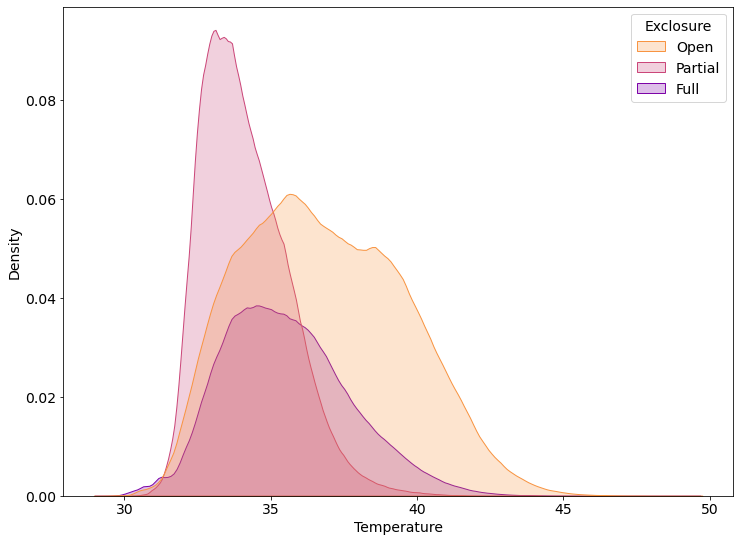

In [49]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r', fill=True, hue_order=exclosure_hues)
fig.savefig(f'./figs/KDEplot_Exclosure_{projstr}.png', dpi=300)

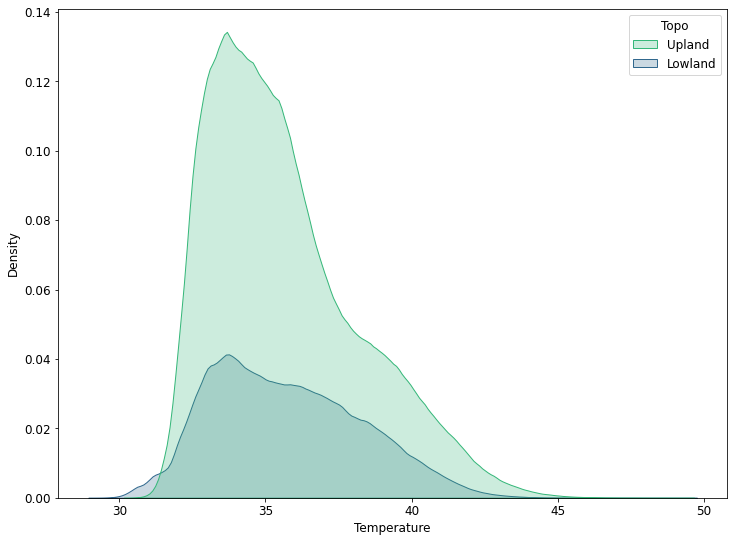

In [50]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Topo', ax=ax, palette='viridis_r', fill=True, hue_order=topo_hues)
fig.savefig(f'./figs/KDEplot_Topo_{projstr}.png', dpi=300)

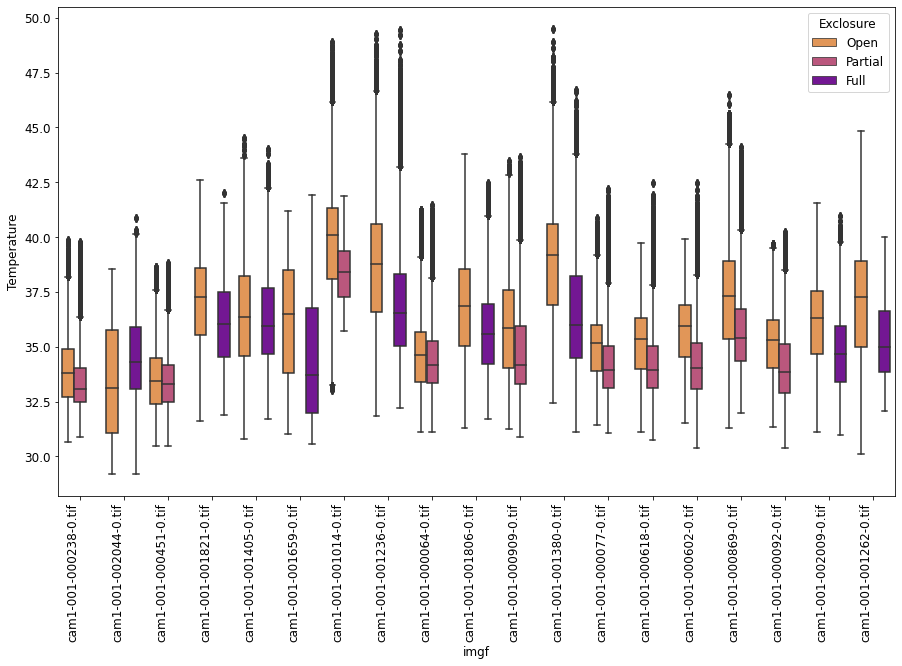

In [71]:
# Newly added 7/25 boxplot by image
plt.rcParams['figure.figsize'] = [15, 9]
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots()
sns.boxplot(data=df_pixels,
            x='imgf', y='Temperature', hue='Exclosure',
            ax=ax, palette='plasma_r', hue_order=exclosure_hues)
plt.xticks(rotation=90, ha='right')

fig.savefig(f'./figs/BoxplotByImage_Exclosure_{projstr}.png', dpi=300)

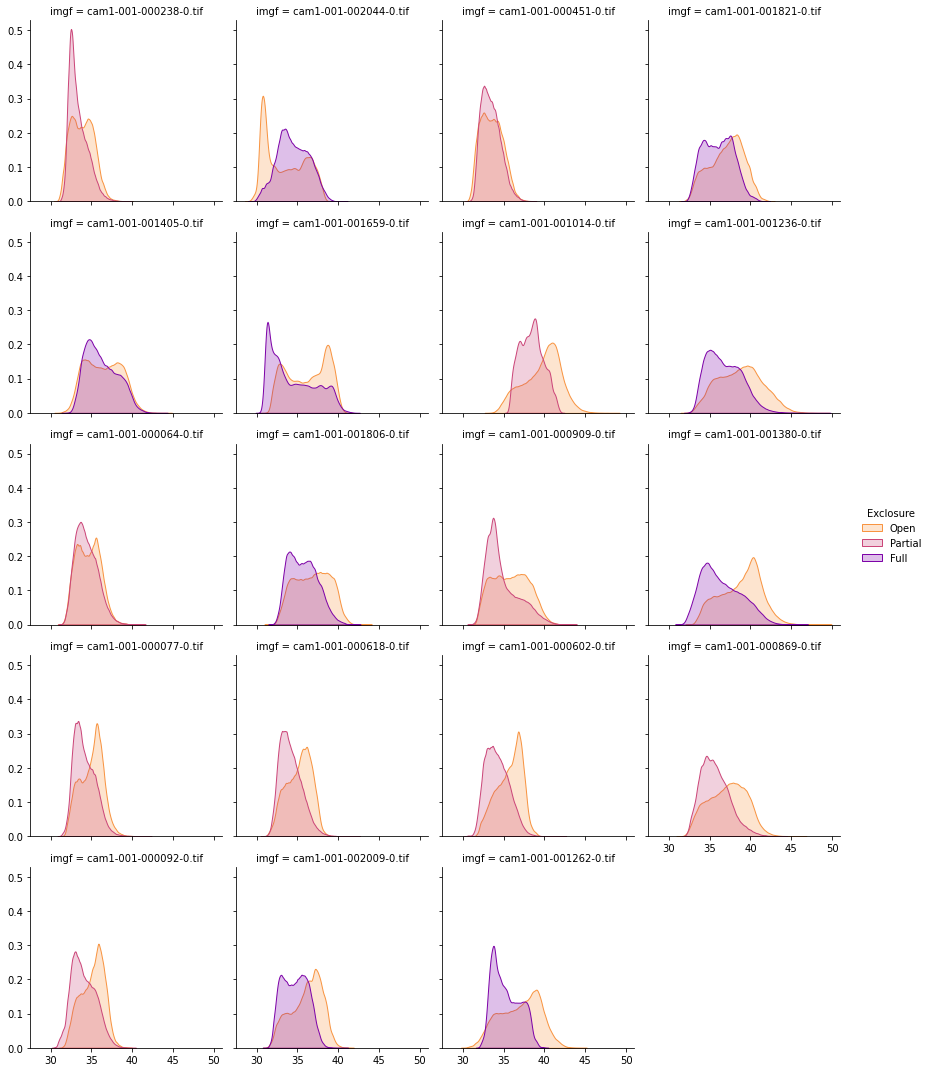

In [51]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Use to dataframe to plot KDE plots in a facetgrid
FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
FG.tight_layout()
# ax.legend()


FG.savefig(f'./figs/KDEPlot_Exclosure_FacetGrid_{projstr}_landscape.png', dpi=300)

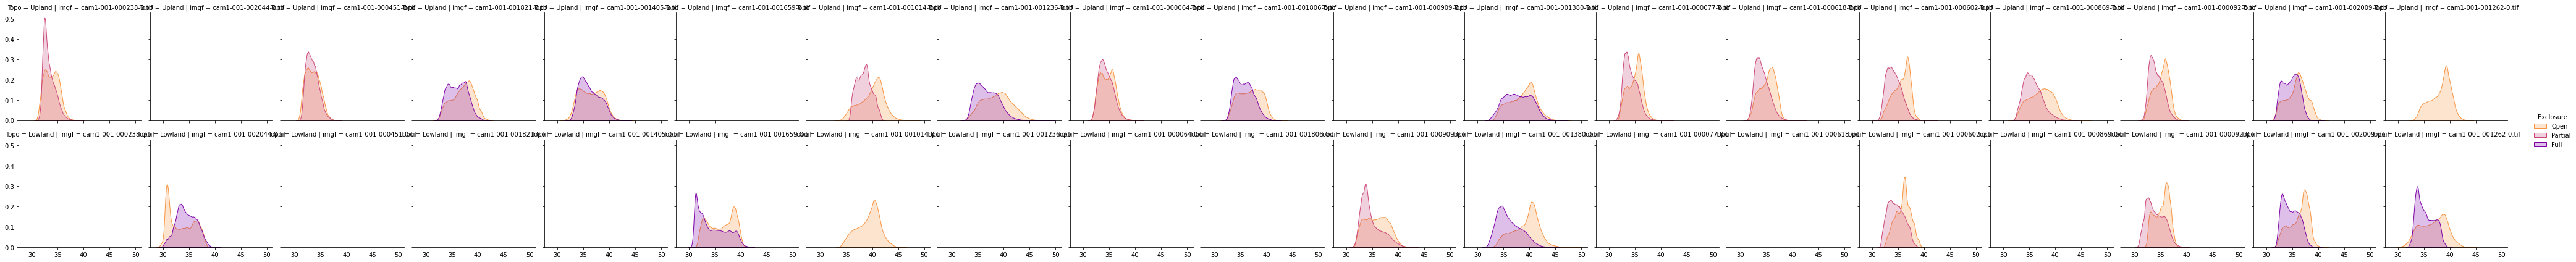

In [ ]:
# Use to dataframe to plot KDE plots in a facetgrid
# sns.kdeplot(pixel_dict['pixels_xr'][ID][idx].data.flatten()-273.15, ax=ax)
# FG = sns.FacetGrid(data=df_pixels, col='Exclosure',  row='imgf')
# FG = sns.FacetGrid(data=df_pixels, row='Topo', col='imgf',  hue='Exclosure', palette='plasma_r', hue_order=exclosure_hues)
# FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
# FG.add_legend()
# # ax.legend()

# FG.savefig(f'./figs/KDEPlot_Topo_FacetGrid_{projstr}_landscape.png', dpi=300)

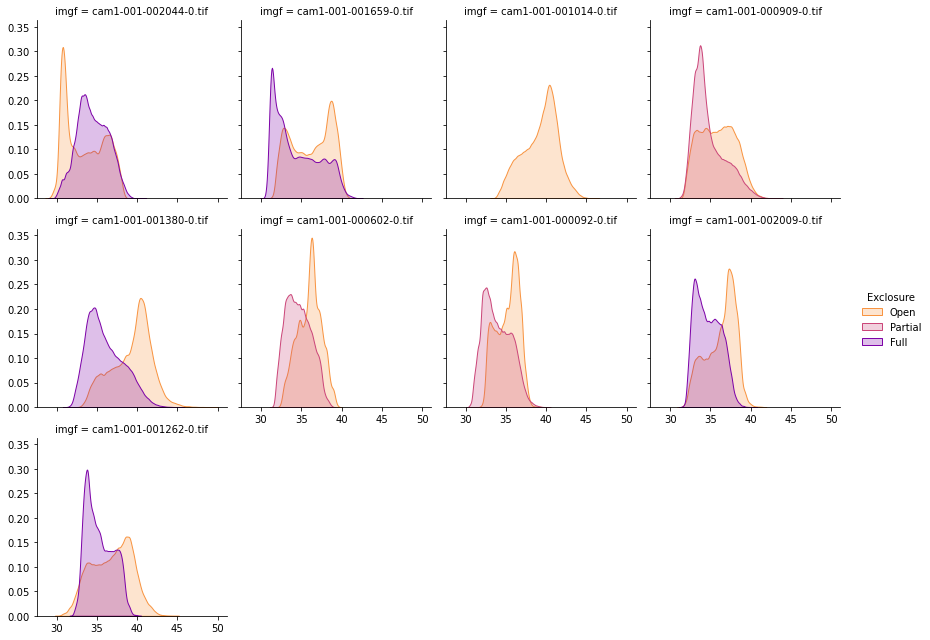

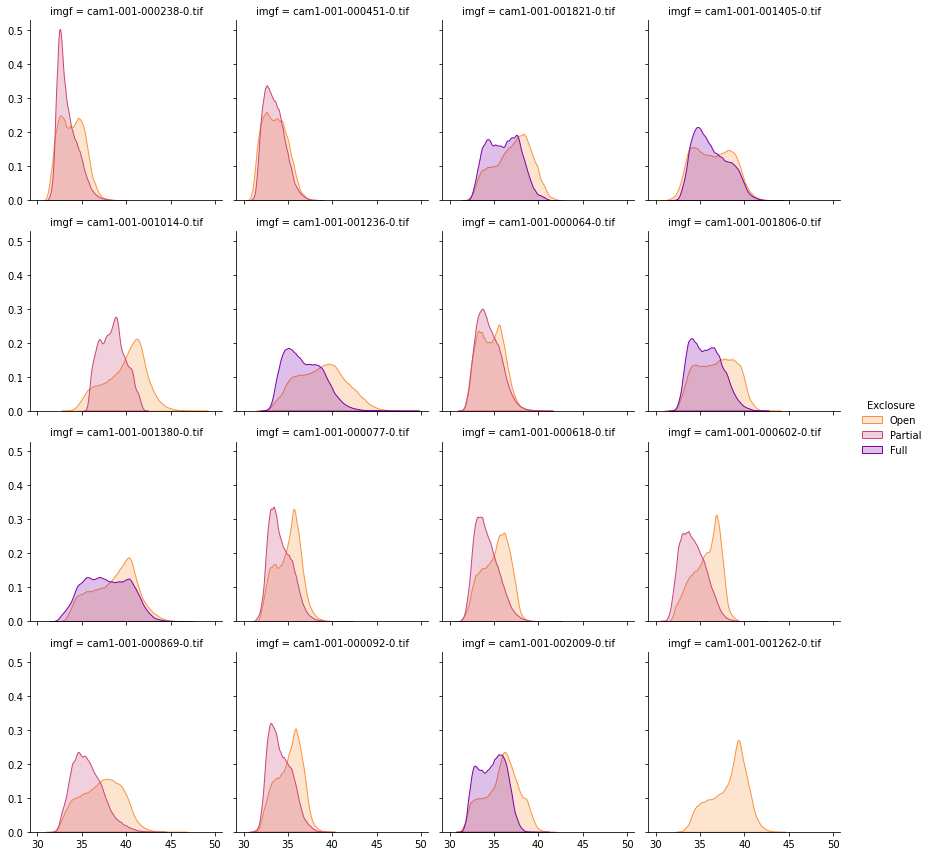

In [53]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Plot Upland and Lowland in seperate Columns
for ul in ['Lowland', 'Upland']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels.loc[df_pixels['Topo']==ul], col='imgf',  hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
    FG.add_legend()
    
    FG.tight_layout()
    # ax.legend()

    FG.savefig(f'./figs/KDEPlot_{ul}_FacetGrid_{projstr}_landscape.png', dpi=300)

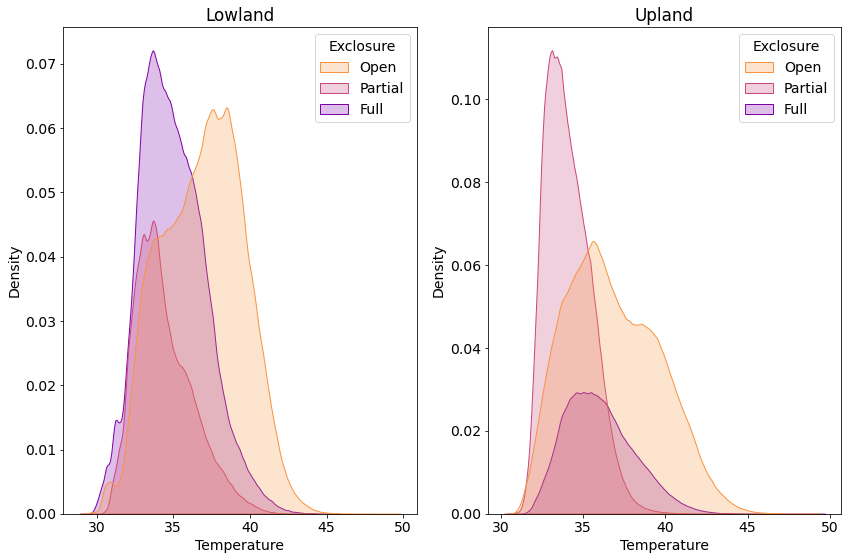

In [54]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(1,2)

# Plot Upland and Lowland in seperate Columns
for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):
    
    sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                x='Temperature',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                hue_order=exclosure_hues,
                fill=True)
                                   
    ax.set_title(f'{ul}')
    
fig.tight_layout()

fig.savefig(f'./figs/KDEPlot_Exclosure_UpLowSplit_{projstr}.png', dpi=300)

## Statistics of Similarity

  #### Difference within overlap zones of images
- Loops through selected images, finds the overlaps between them and all other images
- Then computes mean absolute differece and cohen's d (effect size) between images (time) and exclosures (space)
- Goal: To figure out whether we can use all the images together in analysis, or whether we have to do something else.

Added 7/7/22
Edited 7/29

In [93]:
# Import functions
from Functions_ThermalLandscapes import readThermalImg, plotDiffImages, cohen_d
# from Functions_ThermalLandscapes import meanDiff_ImagesandExclosures


# Function for Making Overlapping Image
# Time and Space Boxplots
# Takes inputs from the above
def timevsspaceBoxplot(p1, p2, i1, i2, shp, projstr):
    
    # Step 1 - create new version of df_img12
    
    # Initialize df list for loop
    df_list = []
    p_list = []

    # For each polygon treatment in the shapefile
    for ID, g in zip(shp.index, shp.geometry):

            # For each image with overlapping pixels
            # for pix, i in zip([pix1_overlap, pix2_overlap], [i1, i2]):

            # Try clipping both images with the features in the shapefile
            try:

                # clip xarray objects of images
                p1 = p1.rio.clip([g], shp.crs, drop=True)
                p2 = p2.rio.clip([g], shp.crs, drop=True)

                # Make a df from each
                pix1_overlap_df = p1.to_dataframe(name=Path(i1).name)
                pix2_overlap_df = p2.to_dataframe(name=Path(i2).name)

                # Drop na rows
                pix1_overlap_df.dropna(axis=0, inplace=True)
                pix2_overlap_df.dropna(axis=0, inplace=True)

                # Drop cols
                pix1_overlap_df.drop(['band', 'spatial_ref'], axis=1, inplace=True)
                pix2_overlap_df.drop(['band', 'spatial_ref'], axis=1, inplace=True)

                # Merge the dataframes (merging on the x, y)
                # This makes a dataframe with x, y, img1 temp, img2 temp, exclosure
                # 1 row for each pixel
                pix12_overlap_df = pd.merge(pix1_overlap_df, pix2_overlap_df, on=['y', 'x'])

                # Assign a new column with the Exclosure
                pix12_overlap_df = pix12_overlap_df.assign(Exclosure=shp.Exclosure[ID])

                # store DataFrame in list
                df_list.append(pix12_overlap_df.copy(deep=True))

            # if it fails, no pixels, move on
            except:
                continue
    
    if len(df_list)>1:
        
        # Concat all the dfs to make a full df 
        df_img12 = pd.concat(df_list, ignore_index=True, sort=False)

        # set nodata values again (rioxarray changes it to 3.4028234663852886e+38)
        df_img12[df_img12 == 3.4028234663852886e+38] = np.nan

        # drop na rows 
        df_img12.dropna(axis=0, inplace=True)

        # STEP 2 - Get differences inside and out
        meanDiff_byImage = []
        meanDiff_byImage_outside = []
        meanDiff_byImage_inside = []
        mdE_df_list = []

        # Group each pixel by exclosure
        df_img12_g = df_img12.groupby(by='Exclosure')

        # if both exclosures have some pixel values
        if df_img12_g.count().size > 0:

            # Now make a bunch of samples for bootstrapping
            for i in range(0, 30):

                i1name = Path(i1).name
                i2name = Path(i2).name

                # Sample df, keeping 25% of the rows in open and partial exclosures
                df_img12_samp = df_img12_g.sample(frac=0.25)

                # Group by Exclosure again, and ...
                df_img12_samp_open = df_img12_samp.loc[df_img12_samp['Exclosure'] == 'Open']
                df_img12_samp_inside = df_img12_samp.loc[((df_img12_samp['Exclosure'] == 'Partial') | (df_img12_samp['Exclosure'] == 'Full'))]

                # 1) Compute the mean difference between exclosures (Space)
                # outside - inside means
                # Note: This will give 2 values, one mean diff per image
                mdE = df_img12_samp_open.drop('Exclosure', axis=1).mean() - df_img12_samp_inside.drop('Exclosure', axis=1).mean()

                # save each mean difference
                # meanDiff_byExclosure_Image1.append(mdE[0])
                # meanDiff_byExclosure_Image2.append(mdE[1])
                # save in a df
                mdE_df = pd.DataFrame(mdE, columns=['ExclosureDiff']).reset_index()
                mdE_df.rename(columns={"index": "imgf"}, inplace=True)

                # 2)  Compute the mean difference between images (Time)

                # All overlapping values difference
                mdI = np.mean(df_img12_samp[i1name] - df_img12_samp[i2name])

                # Overlapping within the open exclosure difference
                mdI_outside = np.mean(df_img12_samp_open[i1name] - df_img12_samp_open[i2name])

                # Overlapping inside the exclosure difference
                mdI_inside = np.mean(df_img12_samp_inside[i1name] - df_img12_samp_inside[i2name])

                meanDiff_byImage.append(mdI)
                meanDiff_byImage_outside.append(mdI_outside)
                meanDiff_byImage_inside.append(mdI_inside)

                # Add the mean difference to the meanDiff by exclosure df
                mdE_df = mdE_df.assign(TimeDiff = mdI)

                # Append to the list to concat outside of the loop
                mdE_df_list.append(mdE_df)

            # Concat
            # each row is now an iteration with the current imagefile
            meanDiff_byEandI_df = pd.concat(mdE_df_list, ignore_index=True)
            meanDiff_byEandI_df.head()

            # Make figure output
            fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
            sns.boxplot(data=meanDiff_byEandI_df, ax=ax1,
                        x='imgf', y='ExclosureDiff')
            sns.boxplot(data=meanDiff_byEandI_df.loc[meanDiff_byEandI_df['imgf'] == i1name],
                        ax=ax2, x='imgf', y='TimeDiff', color='g')
            ax1.set_ylabel('Bootstrapped Mean Temperature Difference [C]')
            ax2.set(xticklabels=[])
            ax2.set(xlabel=f'Image Difference \n {i1name} - {i2name}')
            # fig.legend()
            ax1.set_title('Exclosure Difference')
            ax2.set_ylabel('')
            fig.savefig(f'./figs/TimevsSpace/{projstr}/Boxplots_TimevsSpace_{i1name}_{i2name}.png', dpi=300)
        
        else:
            
            meanDiff_byEandI_df = None

        return meanDiff_byEandI_df

# Function for computing difference in overlapping pixels
# Uses repojection and matching to match img1 to img2
# then computes difference between pixels
# See: https://corteva.github.io/rioxarray/stable/examples/reproject_match.html
def diff_OverlappingPixels(polygon, imgf1, imgf2, shp, projstr):
    
    # Make outstrings for plotting from the filenames
    imgname1 = Path(imgf1).name.split('.tif')[0]
    imgname2 = Path(imgf2).name.split('.tif')[0]

    # If they're the same image, just skip it!
    if imgname1==imgname2:
        
        diff = np.nan
        diff_mean = 0
        diff_std = 0
        cd = 0
        OPdiff_img1 = np.nan
        OPdiff_img2 = np.nan
        imgdiff = 0
        df_img12 = np.nan
        meanDiff_byEandI_df = np.nan
        
    # Otherwise...
    else:
        
        # Read in both images
        # Returns an image in Celcius
        img1 = readThermalImg(imgf1)
        img2 = readThermalImg(imgf2)
        
        # Clip the pixels of each using the intersection polygon
        pix1 = img1.rio.clip([polygon], drop=True)
        pix2 = img2.rio.clip([polygon], drop=True)
        
        # set no data
        pix1 = pix1.where((pix1 < 150) & (pix1 >= 0))
        pix2 = pix2.where((pix2 < 150) & (pix2 >= 0))

        # Make a new pix2 matching the projection of pix1
        pix2_match = pix2.rio.reproject_match(pix1)

        # Set the coordinates of the grid (same as pix1)
        pix2_match.assign_coords({"x": pix1.x,
                                  "y": pix1.y})

        # Compute the pixel-wise difference
        diff = pix1 - pix2_match

        # Compute Summary Stats (absolute values)
        diff_mean = np.nanmean(np.abs(diff.data.flatten()))
        diff_std = np.nanstd(np.abs(diff.data.flatten()))
                                   
        # Plot the differences, if there are any
        if not(np.isnan(diff_mean)):
            
            plotDiffImages(pix1=pix1,
                           pix2=pix2_match,
                           diff=diff,
                           projstr=projstr,
                           outstr1=imgname1,
                           outstr2=imgname2)
         
        # Test Exclosure differences within overlap areas
        
        # Get only the overlap pixels in each image
        # Cutting out edges that are in the overlap zones, but are na
        pix1_overlap = pix1.where(diff.notnull())
        pix2_overlap = pix2_match.where(diff.notnull())
        
        # Compute cohen's d (measure of effect size)
        # Standardized mean difference between the two
        cd = cohen_d(pix1_overlap, pix2_overlap)
        
        # Apply a function to clip the overlapping areas with polygons again
        # and return a variety of values
        OPdiff_img1, OPdiff_img2, imgdiff, df_img12 = meanDiff_ImagesandExclosures(pix1_overlap,
                                                                                   pix2_overlap,
                                                                                   i1=imgf1,
                                                                                   i2=imgf2,
                                                                                   shp=shp,
                                                                                   printvalues=True,
                                                                                   includepartial=False)
        
        # Make a time vs space boxplot
        meanDiff_byEandI_df = timevsspaceBoxplot(p1=pix1_overlap,
                                                 p2=pix2_overlap,
                                                 i1=imgf1,
                                                 i2=imgf2,
                                                 projstr=projstr,
                                                 shp=shp)

    
    return diff, diff_mean, diff_std, cd, OPdiff_img1, OPdiff_img2, imgdiff, df_img12, meanDiff_byEandI_df

def meanDiff_ImagesandExclosures(pix1_overlap, pix2_overlap, i1, i2, shp=shp, printvalues=False, includepartial=False):
    
    # This Function clips the overlap zones of 2 images with exclosure polygons
    # It returns:
    # the pixel values (OPdiff_img1, OPdiff_img2)
    # The mean differences between images in the overlap zone (imgdiff) 
    # The mean differences between exclosure treatments (df_img12)
    # NOTE: This may not work well if the area overlaps more than 2 exclosure treatments (Open & Partial & Full all at once)
    
    # Inputs pix1_overlap and pix2_overlap are the overlapping pixels of 2 image files
    # i1 and i2 are the full paths to both img files
    # shp is a geodataframe of the shapefile polygons
    # print values will spit out a mean absolute difference if True
    
    # 7/25 - Filter shapefile for only the full and open exclosure types
    # Andrew doesn't want partial in the equation
    if includepartial:
        shp_filter = shp.copy()
    else:
        shp_filter = shp[shp.Exclosure != 'Partial']
    
    # Initialize df list for loop
    df_list = []

    # For each polygon treatment in the shapefile
    for ID, g in zip(shp_filter.index, shp_filter.geometry):

        # For each image with overlapping pixels
        for pix, i in zip([pix1_overlap, pix2_overlap], [i1, i2]):

            # Try clipping the image with the feature in the shapefile
            try:
                
                p = pix.rio.clip([g], shp.crs, drop=True)

                # Initialize an empty df
                df = pd.DataFrame()

                # img name
                iname = Path(i).name

                # Make an exploded dataframe, with each pixel noted by it's treatment and imgfile
                df = pd.DataFrame({'Temperature':p.data.flatten(),
                                   'Exclosure':shp_filter.Exclosure.iloc[ID],
                                   'imgf':iname})

                # Drop na rows
                df.dropna(axis=0, how='any', inplace=True)

                # store DataFrame in list
                df_list.append(df.copy(deep=True))

            # if it fails, no pixels, move on
            except:
                continue
        
    if len(df_list)>1:
            
        # Concat all the dfs to make a full df 
        df_img12 = pd.concat(df_list, ignore_index=True, sort=False)

        # set nodata values again (rioxarray changes it to 3.4028234663852886e+38)
        df_img12[df_img12 == 3.4028234663852886e+38] = np.nan

        # Group by Exclosure and Images
        df_img12_g = df_img12.groupby(['Exclosure','imgf'])
        df_img12_img_g = df_img12.groupby(['imgf'])

        # If there are 2 images and 2 exclosure types to work with:
        if (df_img12_g.mean().shape[0] >= 4):

            # Take the absolute mean difference in exclosures per image
            OPdiff_img1 = df_img12_g.mean().iloc[0] - df_img12_g.mean().iloc[2]
            OPdiff_img2 = df_img12_g.mean().iloc[1] - df_img12_g.mean().iloc[3]

            # Just return single value
            OPdiff_img1 = OPdiff_img1.values[0]
            OPdiff_img2 = OPdiff_img2.values[0]

            # Mean difference between images
            imgdiff = df_img12_img_g.mean().iloc[0] - df_img12_img_g.mean().iloc[1]
            imgdiff = imgdiff.values[0]

        else:

            OPdiff_img1 = np.nan
            OPdiff_img2 = np.nan
            imgdiff = np.nan

        # Print the means
        # What we want to see here is that the differences in exclosure temperatures
        # are consistent between images    
        if printvalues:
            print(f'Overlap Zones \n Exclosure Temp Difference: \n \t {Path(i1).name}: {OPdiff_img1} \n \t {Path(i2).name}: {OPdiff_img2}')
            print(f' Difference Between Images: \n \t {imgdiff}')
    else:

            OPdiff_img1 = np.nan
            OPdiff_img2 = np.nan
            imgdiff = np.nan
            df_img12 = None
        
    # Return df of pixels, and mean difference values
    return OPdiff_img1, OPdiff_img2, imgdiff, df_img12

/tmp/ipykernel_260626/1227418831.py:201: RuntimeWarning: Mean of empty slice
  diff_mean = np.nanmean(np.abs(diff.data.flatten()))
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(
/n/home02/

Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-002044-0.tif: nan 
 	 cam1-001-002009-0.tif: nan
 Difference Between Images: 
 	 nan


/tmp/ipykernel_260626/1227418831.py:201: RuntimeWarning: Mean of empty slice
  diff_mean = np.nanmean(np.abs(diff.data.flatten()))
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(
/n/home02/

Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-001821-0.tif: nan 
 	 cam1-001-001806-0.tif: nan
 Difference Between Images: 
 	 nan


/tmp/ipykernel_260626/1227418831.py:201: RuntimeWarning: Mean of empty slice
  diff_mean = np.nanmean(np.abs(diff.data.flatten()))
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


...

/tmp/ipykernel_260626/1227418831.py:201: RuntimeWarning: Mean of empty slice
  diff_mean = np.nanmean(np.abs(diff.data.flatten()))
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-001262-0.tif: nan 
 	 cam1-001-001014-0.tif: nan
 Difference Between Images: 
 	 nan


/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-001262-0.tif: -1.4446487426757812 
 	 cam1-001-001380-0.tif: -1.0080070495605469
 Difference Between Images: 
 	 -1.8078689575195312


NameError: name 'saveMatrixResults' is not defined

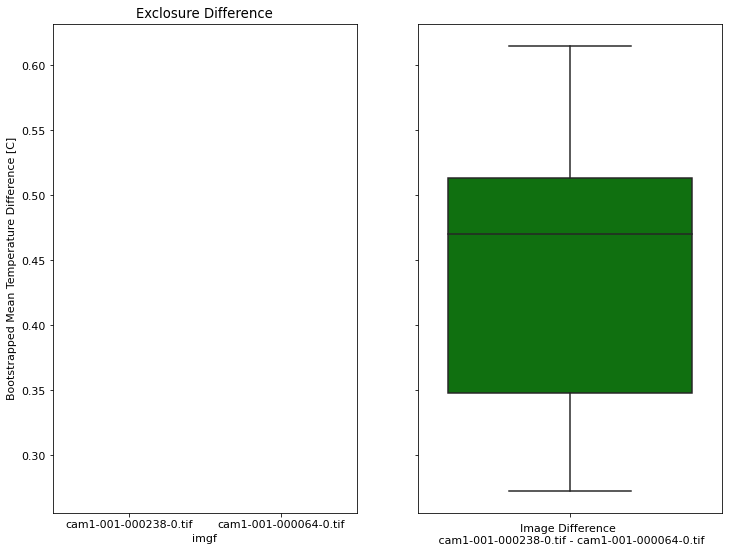

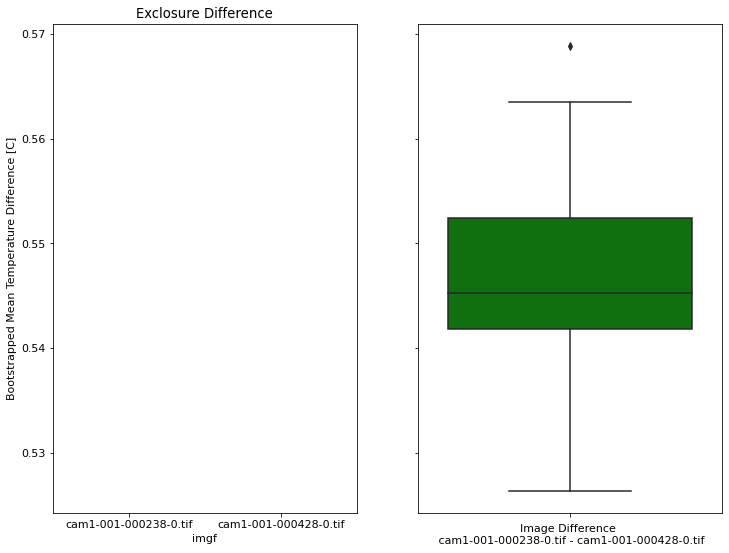

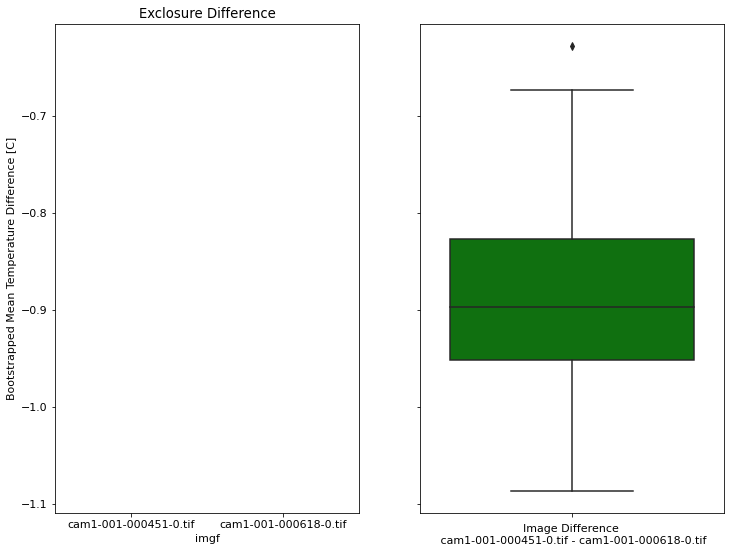

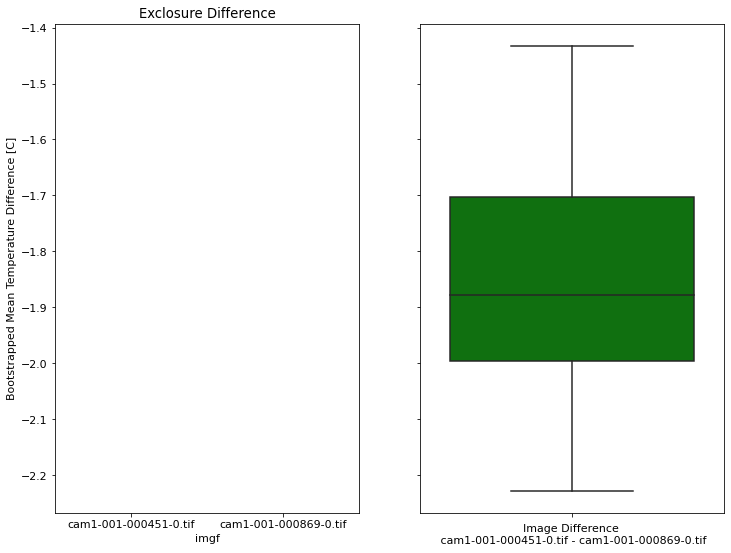

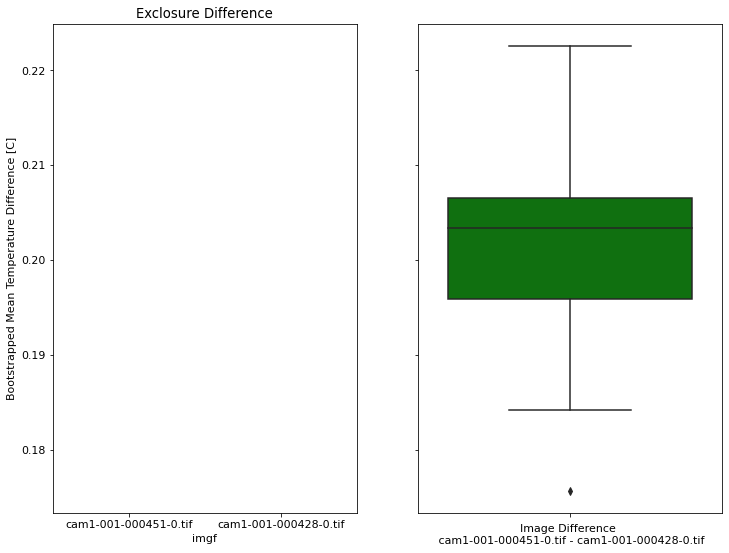

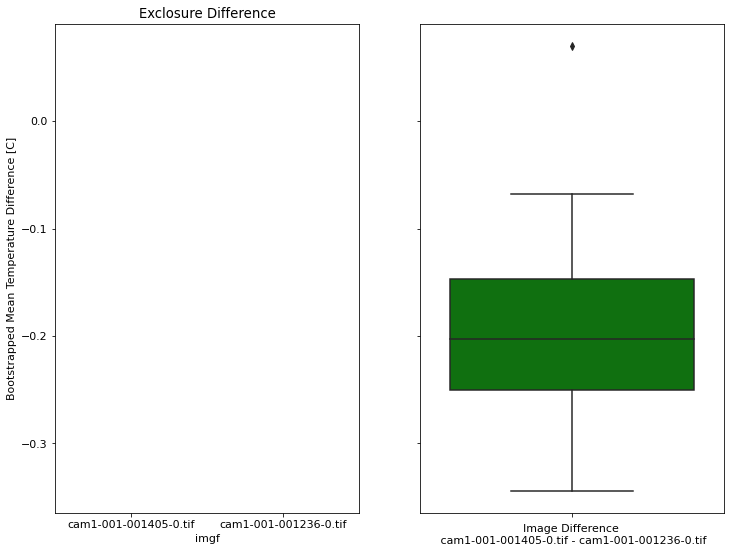

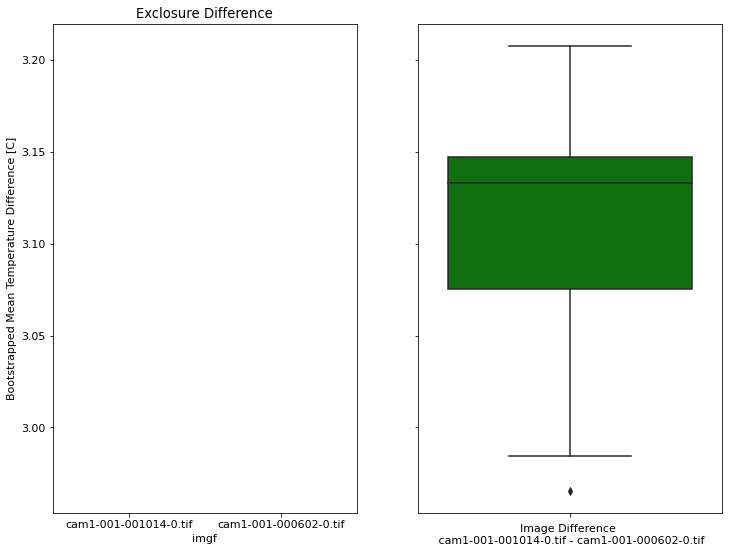

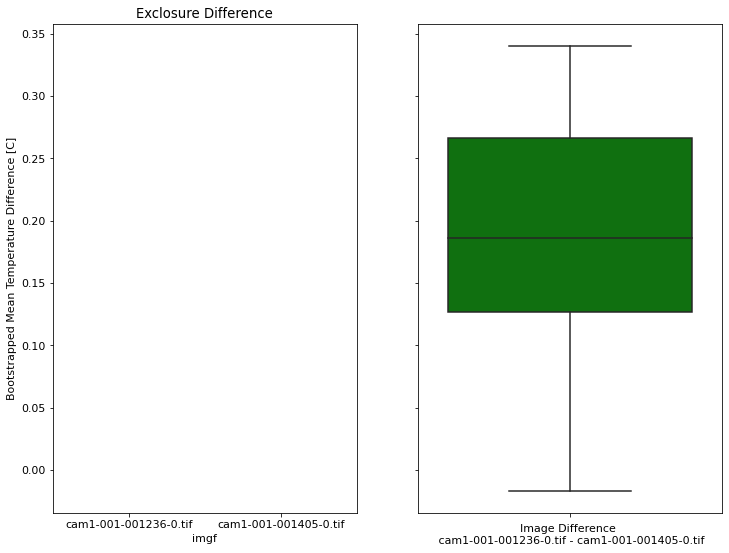

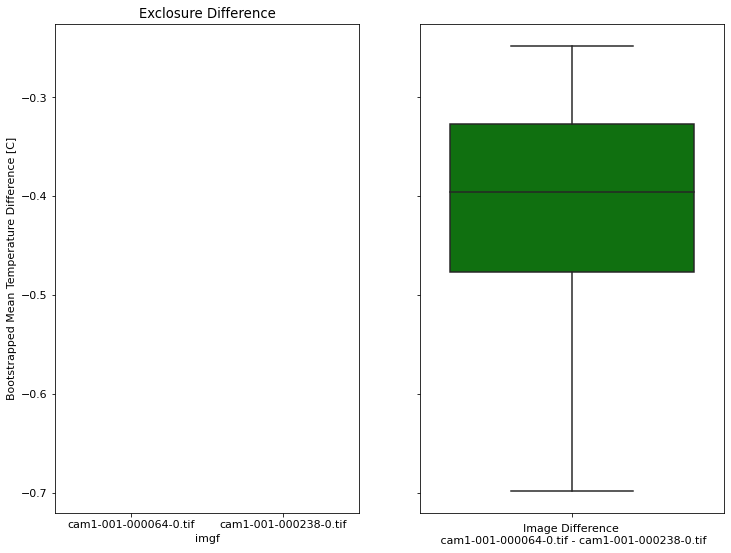

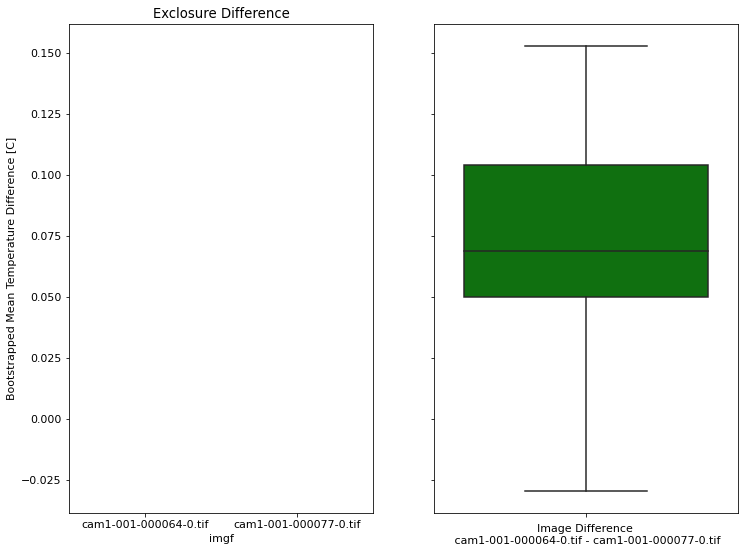

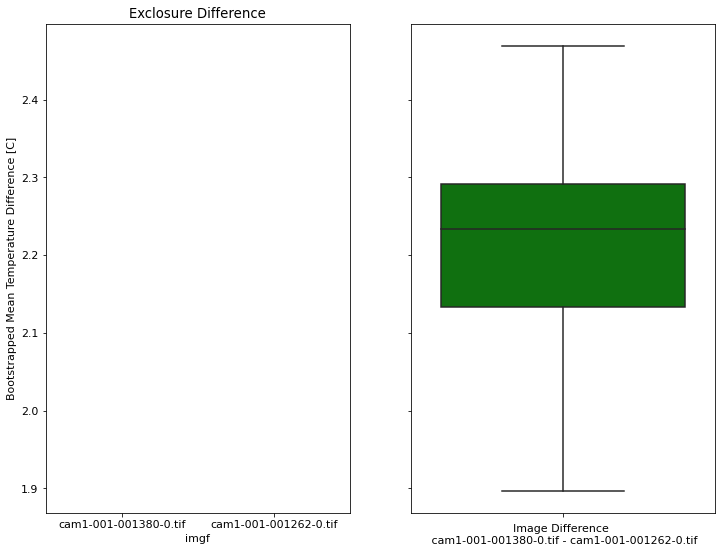

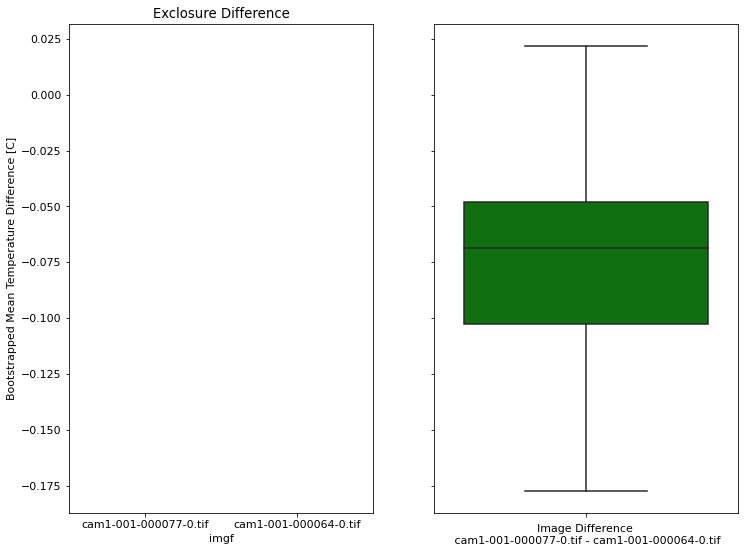

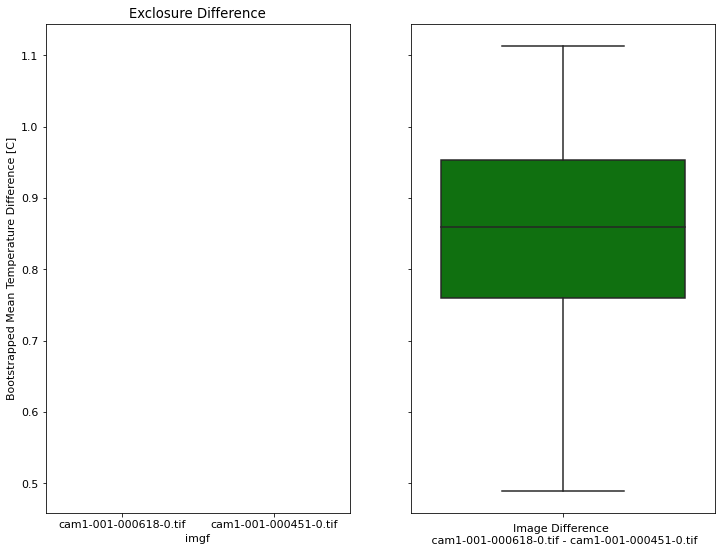

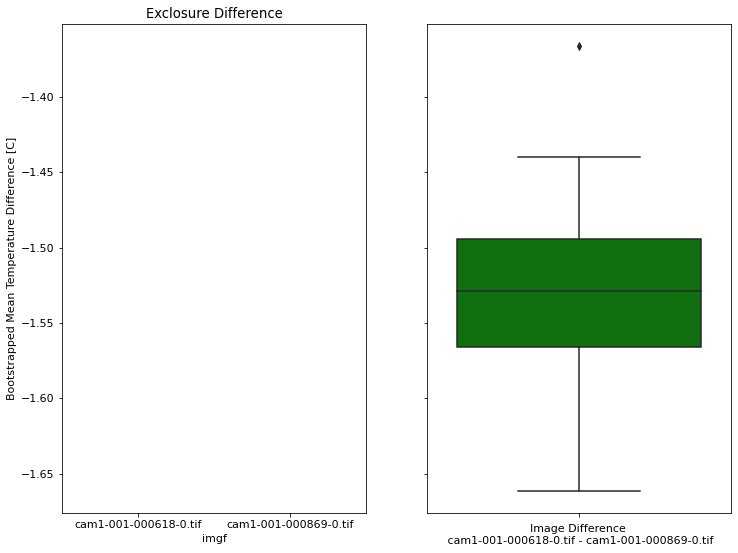

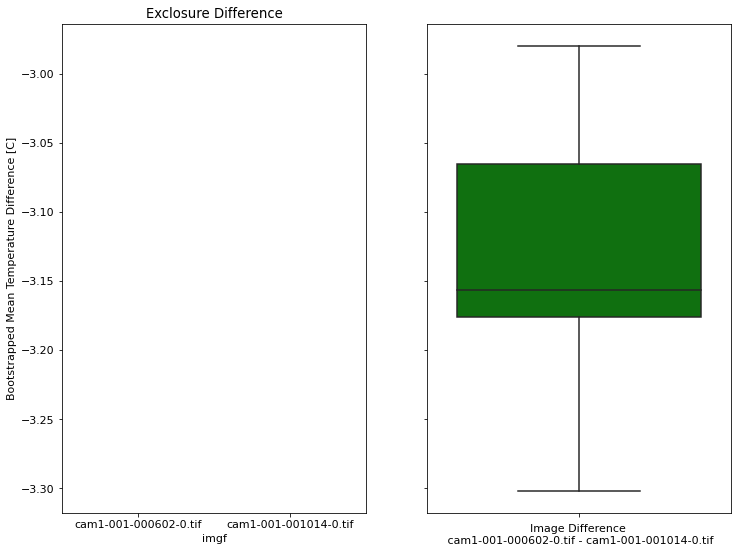

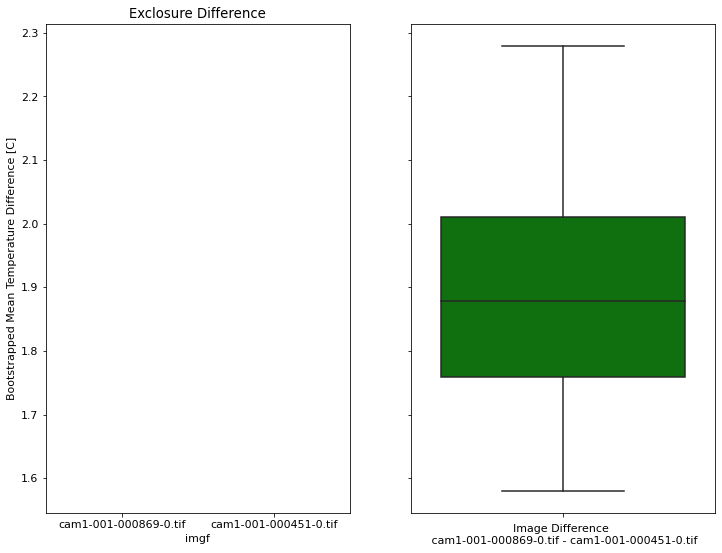

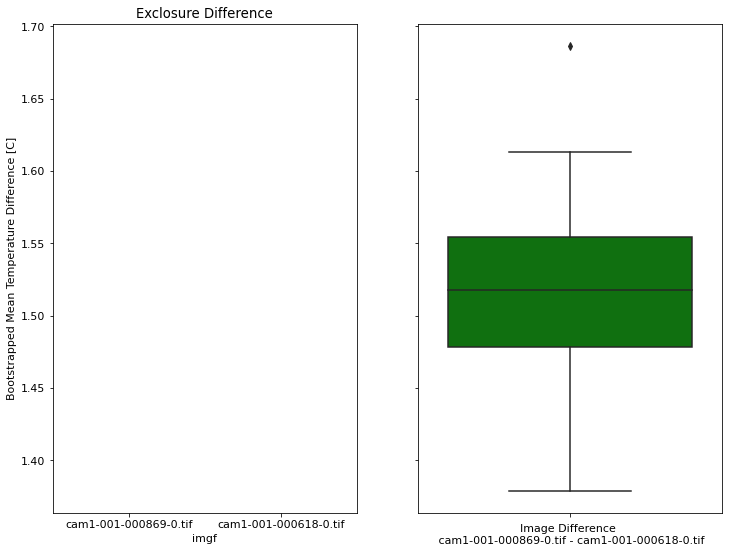

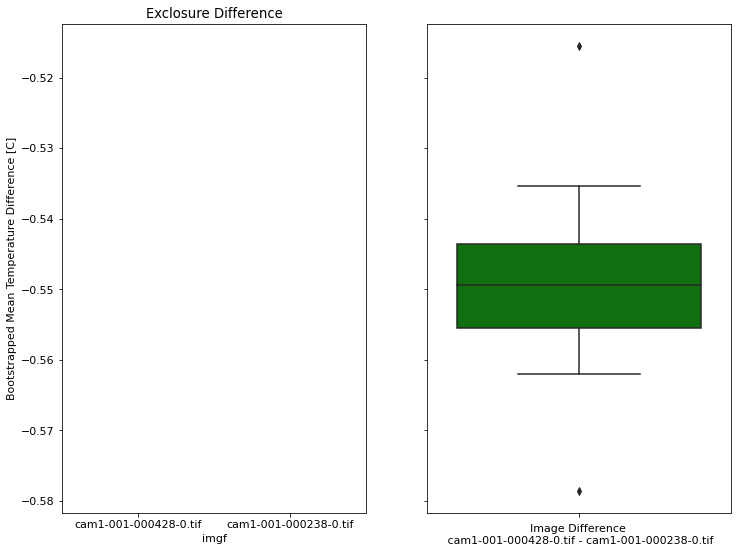

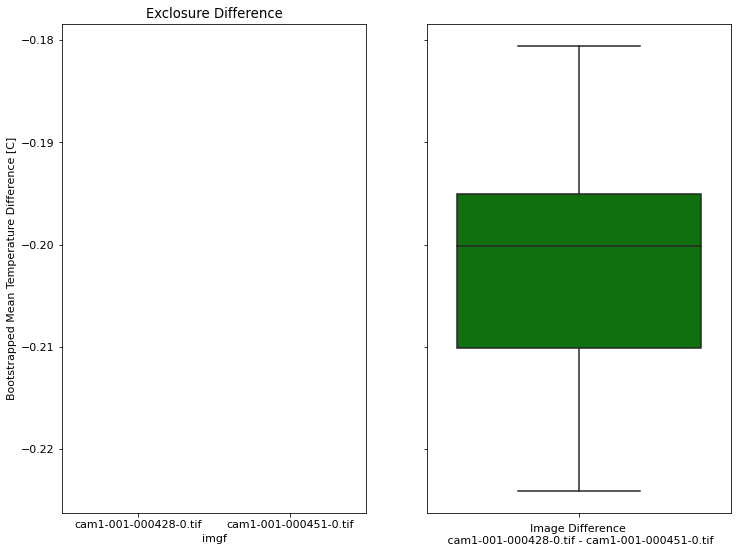

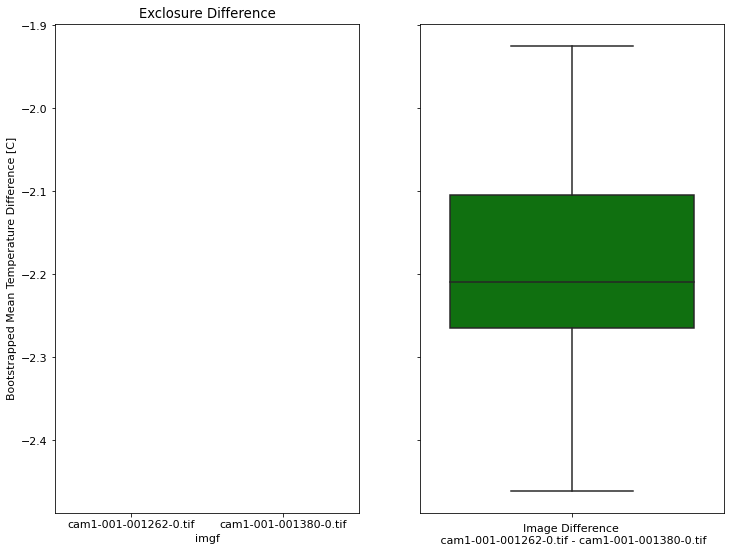

In [94]:
# Processing Loop

# Make a geoseries of all the imgfiles and their boundary polygons
poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], 
                        index=img_dict['imgf'],
                        crs='EPSG:32736')

# Make a shapefile of just the Full and Open Exclosure Types
# shp_filter = shp[shp.Exclosure != 'Partial']
shp_filter = shp.copy()


diff_list = []
diffmean_list = []
diffstd_list = []
cd_list = []
img1_list = []
img2_list = []
intersects_list = []
meanDiff_spacetime_list = []

# for each image combination
for img1, poly1 in poly_gs.iteritems():
    for img2, poly2 in poly_gs.iteritems():
        
        strt = time.time()
        
        img1_list.append(img1)
        img2_list.append(img2)
        
        intersects_list.append(poly1.intersects(poly2))
        
        # Check for intersection
        if poly1.intersects(poly2):

            # Get the intersection
            intersection = poly1.intersection(poly2)
            
            # NOTE: Could put in here an intersection cutoff to only get image intersections with high overlap (> 20% for instance)
            # if intersection.area/poly1.area >=0.2:

            # Calculate a bunch of stuff
            d, d_mean, d_std, cd, OPdiff_img1, OPdiff_img2, imgdiff, df_img12, meanDiff_byEandI_df = diff_OverlappingPixels(intersection,
                                                                                                                           f'{img_dir}/{img1}',
                                                                                                                           f'{img_dir}/{img2}',
                                                                                                                           shp=shp_filter,
                                                                                                                           projstr=projstr)
            # append space time dataframe from boxplot
            meanDiff_spacetime_list.append(meanDiff_byEandI_df)


            diff_list.append(d)
            diffmean_list.append(d_mean)
            diffstd_list.append(d_std)

        else:

            # ks_results.append(np.nan)
            diff_list.append(np.nan)
            diffmean_list.append(np.nan)
            diffstd_list.append(np.nan)
            meanDiff_spacetime_list.append(np.nan)

        end = time.time()

        # print(f'{end-strt} seconds')
        # time.sleep(1)
        
# Combine results, and save
diffmean_df = saveMatrixResults(diffmean_list, 
                          projname=projstr,
                          outstr='MeanPixelDiff_OverlapZones',
                          rowcolnames=poly_gs.index,
                          m=poly_gs.shape[0],
                          n=poly_gs.shape[0])

diffstd_df = saveMatrixResults(diffstd_list, 
                          projname=projstr,
                          outstr='StdPixelDiff_OverlapZones',
                          rowcolnames=poly_gs.index,
                          m=poly_gs.shape[0],
                          n=poly_gs.shape[0])


In [64]:
# Assign a new column to the full gdf of images (all images taken here) with img number
img_gdf_filter = img_gdf_filter.assign(imgf = img_gdf_filter.img.apply(lambda x: Path(x).name))
# Add a new column with the exact number of the image (for sorting)
img_gdf_filter = img_gdf_filter.assign(imgnum = img_gdf_filter.img.apply(lambda x: int(Path(x).name.split('-')[-2])))

# Select for only images that overlap the full and the open
img_gdf_filter_full = img_gdf_filter.loc[(img_gdf_filter['OverlapsFull'] & img_gdf_filter['OverlapsOpen'])]

# Sort by evenness, then overlap
img_gdf_filter_full.sort_values(by=['imgnum', 'Evenness', 'Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)

# Now look, and select just a few image combos
img_gdf_filter_full.head()

/tmp/ipykernel_260626/3488565076.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  img_gdf_filter_full.sort_values(by=['imgnum', 'Evenness', 'Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)


,img,geometry,Area Full 0,Overlap Full 0,Area Full 1,Overlap Full 1,Area Partial 2,Overlap Partial 2,Area Partial 3,Overlap Partial 3,...,Overlap Open 7,Area Open 8,Overlap Open 8,Sum,Evenness,OverlapsFull,OverlapsPartial,OverlapsOpen,imgf,imgnum
0,/n/holystore01/LABS/davies_lab/Lab/data/produc...,"POLYGON ((339841.800 7371670.200, 340118.400 7...",0.0,0.0,17559.517341,0.084848,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.416155,-0.592226,True,False,True,cam1-001-002168-0.tif,2168
1,/n/holystore01/LABS/davies_lab/Lab/data/produc...,"POLYGON ((339849.900 7371663.300, 340125.900 7...",0.0,0.0,17372.863633,0.083947,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.371192,-0.547692,True,False,True,cam1-001-002167-0.tif,2167
2,/n/holystore01/LABS/davies_lab/Lab/data/produc...,"POLYGON ((339867.900 7371651.000, 340144.200 7...",0.0,0.0,17350.260845,0.083837,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.293728,-0.429150,True,False,True,cam1-001-002166-0.tif,2166
3,/n/holystore01/LABS/davies_lab/Lab/data/produc...,"POLYGON ((339873.300 7371639.600, 340149.300 7...",0.0,0.0,15784.599883,0.076272,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.242537,-0.371050,True,False,True,cam1-001-002165-0.tif,2165
4,/n/holystore01/LABS/davies_lab/Lab/data/produc...,"POLYGON ((339890.100 7371630.900, 340166.400 7...",0.0,0.0,15708.906689,0.075906,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.194973,-0.221367,True,False,True,cam1-001-002164-0.tif,2164


/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-002168-0.tif: 0.6905441284179688 
 	 cam1-001-002167-0.tif: 0.7179641723632812
 Difference Between Images: 
 	 -0.07057571411132812


/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-002168-0.tif: -0.43457794189453125 
 	 cam1-001-002166-0.tif: -0.5539588928222656
 Difference Between Images: 
 	 -0.2935028076171875


/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


...

/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-002167-0.tif: -1.9541587829589844 
 	 cam1-001-002165-0.tif: -2.2041854858398438
 Difference Between Images: 
 	 -0.2840232849121094


/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-002167-0.tif: nan 
 	 cam1-001-002164-0.tif: nan
 Difference Between Images: 
 	 nan


KeyboardInterrupt: 

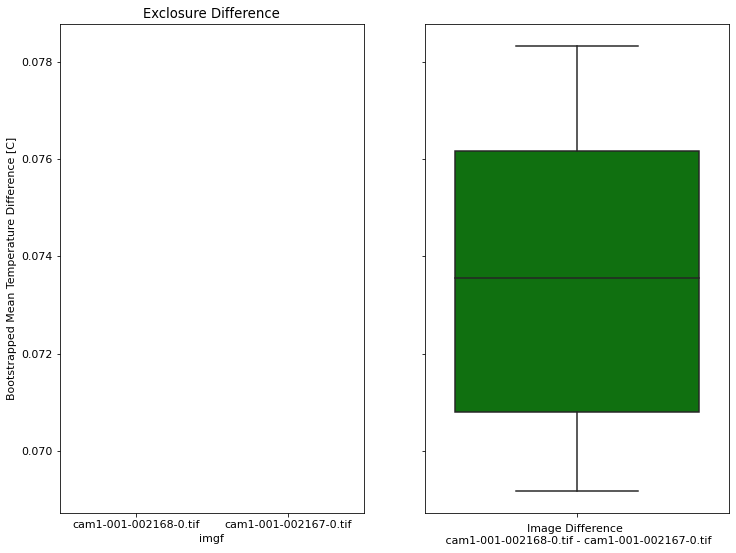

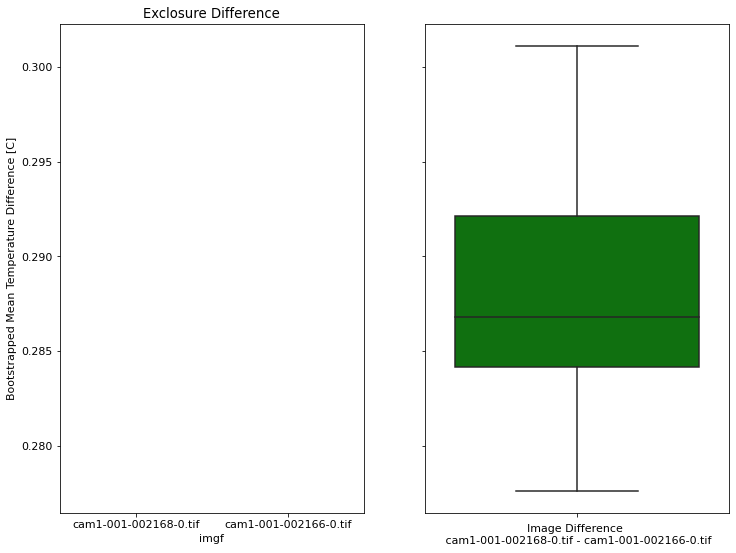

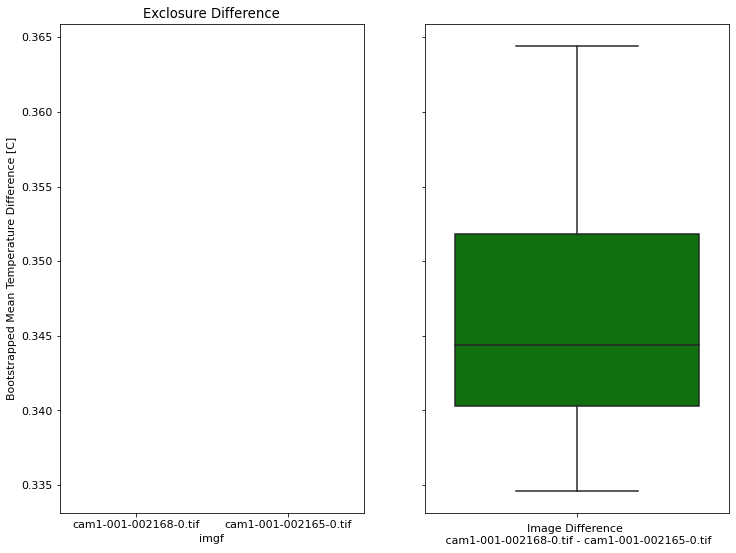

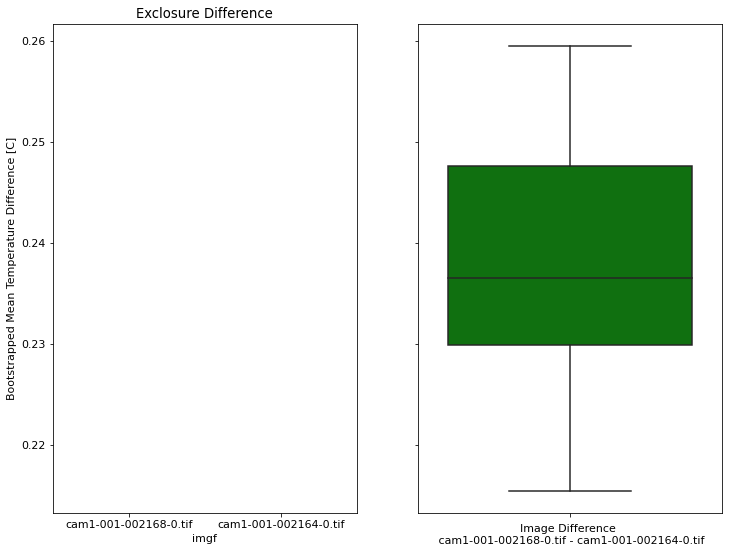

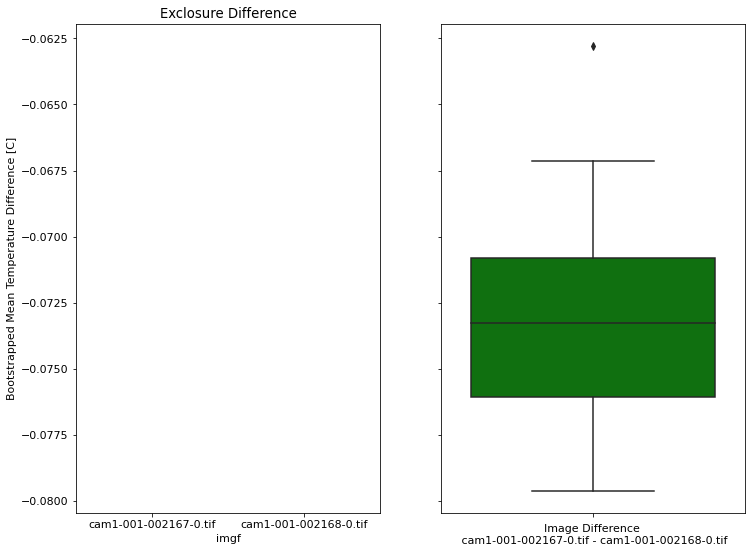

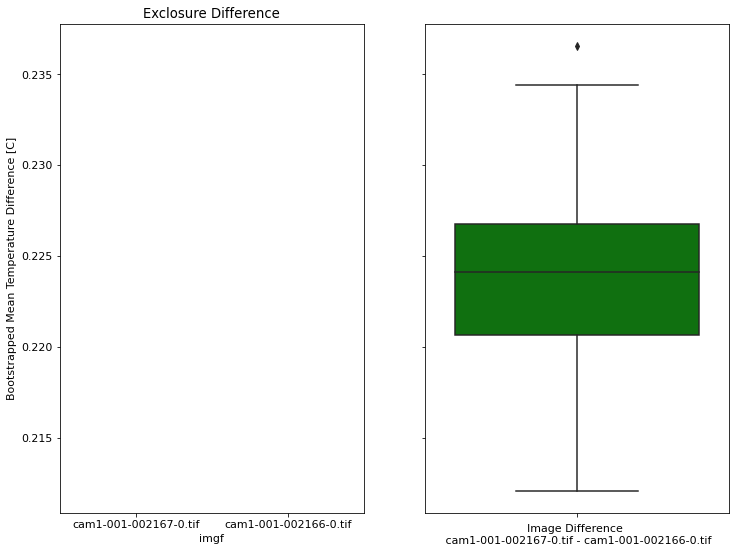

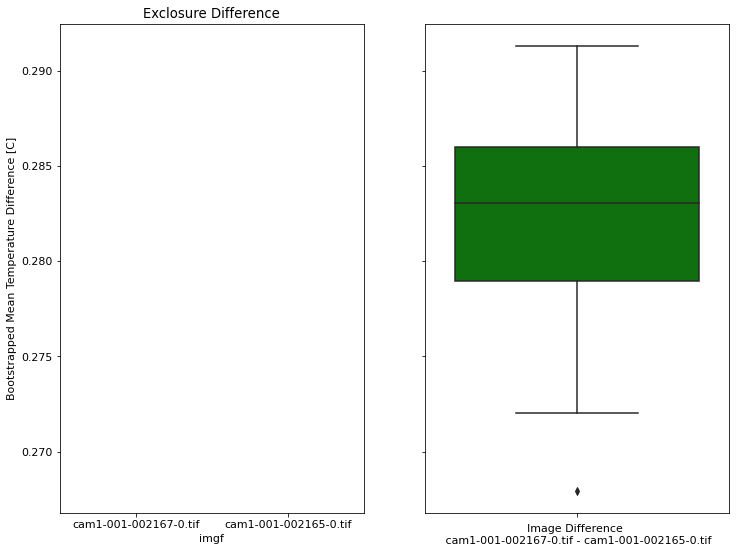

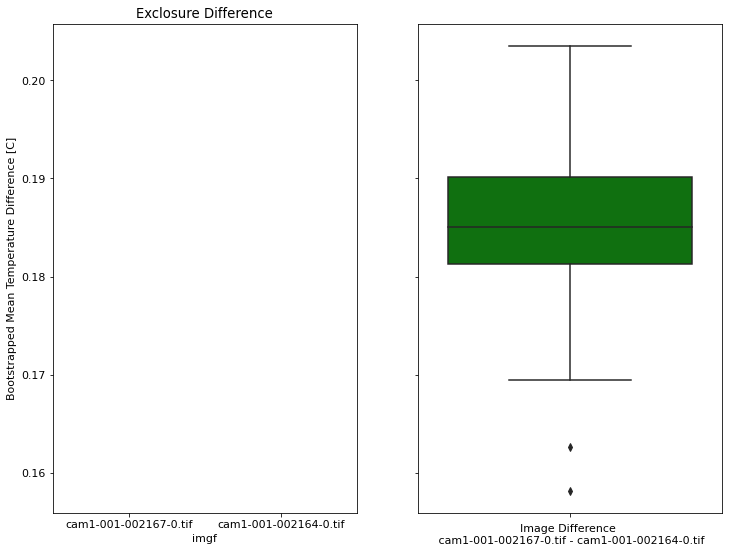

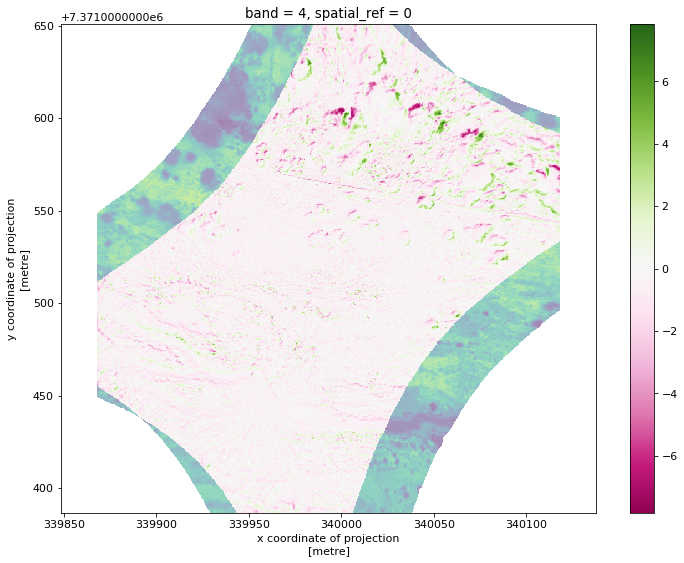

In [83]:
# Make a geodf to Loop through just a few images with high overlap, and overlapping the full exclosure
poly_gdf_highoverlap = img_gdf_filter_full.loc[((img_gdf_filter_full['imgnum'] >= 2164) & (img_gdf_filter_full['imgnum'] <= 2168))]\

# Make a shapefile of just the Full and Open Exclosure Types
# shp_filter = shp[shp.Exclosure != 'Partial']
shp_filter = shp.copy()


diff_list = []
diffmean_list = []
diffstd_list = []
cd_list = []
img1_list = []
img2_list = []
intersects_list = []
meanDiff_spacetime_list = []

# for each image combination
for img1, poly1 in zip(poly_gdf_highoverlap.imgf, poly_gdf_highoverlap.geometry.values):
    for img2, poly2 in zip(poly_gdf_highoverlap.imgf, poly_gdf_highoverlap.geometry.values):
        
        strt = time.time()
        
        img1_list.append(img1)
        img2_list.append(img2)
        
        intersects_list.append(poly1.intersects(poly2))
        
        # Check for intersection
        if poly1.intersects(poly2):

            # Get the intersection
            intersection = poly1.intersection(poly2)
            
            # NOTE: Could put in here an intersection cutoff to only get image intersections with high overlap (> 20% for instance)
            # if intersection.area/poly1.area >=0.2:

            # Calculate a bunch of stuff
            d, d_mean, d_std, cd, OPdiff_img1, OPdiff_img2, imgdiff, df_img12, meanDiff_byEandI_df = diff_OverlappingPixels(intersection,
                                                                                                                           f'{img_dir}/{img1}',
                                                                                                                           f'{img_dir}/{img2}',
                                                                                                                           shp=shp_filter,
                                                                                                                           projstr=projstr)
            # append space time dataframe from boxplot
            meanDiff_spacetime_list.append(meanDiff_byEandI_df)


            diff_list.append(d)
            diffmean_list.append(d_mean)
            diffstd_list.append(d_std)

        else:

            # ks_results.append(np.nan)
            diff_list.append(np.nan)
            diffmean_list.append(np.nan)
            diffstd_list.append(np.nan)
            meanDiff_spacetime_list.append(np.nan)

        end = time.time()

In [ ]:
d

## TESTING


In [74]:
OPdiff_img1, OPdiff_img2, imgdiff, df_img12 = meanDiff_ImagesandExclosures(pix1_overlap, pix2_overlap, i1, i2, printvalues=True)

/n/home02/pbb/.conda/envs/Halo/lib/python3.8/site-packages/rioxarray/raster_writer.py:110: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


Overlap Zones 
 Exclosure Temp Difference: 
 	 cam1-001-001014-0.tif: 0.44698333740234375 
 	 cam1-001-000602-0.tif: 1.0608634948730469
 Difference Between Images: 
 	 -3.699260711669922


No handles with labels found to put in legend.


Text(0, 0.5, '')

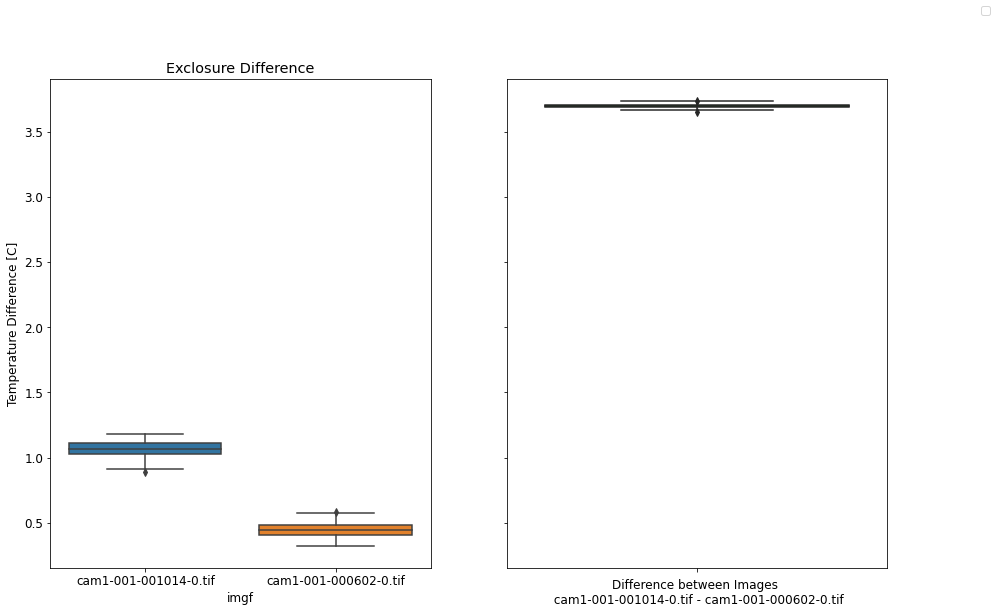

In [243]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
sns.boxplot(data=meanDiff_byEandI_df, ax=ax1,
            x='imgf', y='ExclosureDiff')
sns.boxplot(data=meanDiff_byEandI_df.loc[meanDiff_byEandI_df['imgf'] == Path(i2).name],
            ax=ax2, x='imgf', y='TimeDiff', color='g')
ax1.set_ylabel('Temperature Difference [C]')
ax2.set(xticklabels=[])
ax2.set(xlabel=f'Difference between Images \n {Path(i1).name} - {Path(i2).name}')
fig.legend()
ax1.set_title('Treatment')
ax2.set_title('Time')
ax2.set_ylabel('')

<AxesSubplot:xlabel='cam1-001-001014-0.tif', ylabel='Density'>

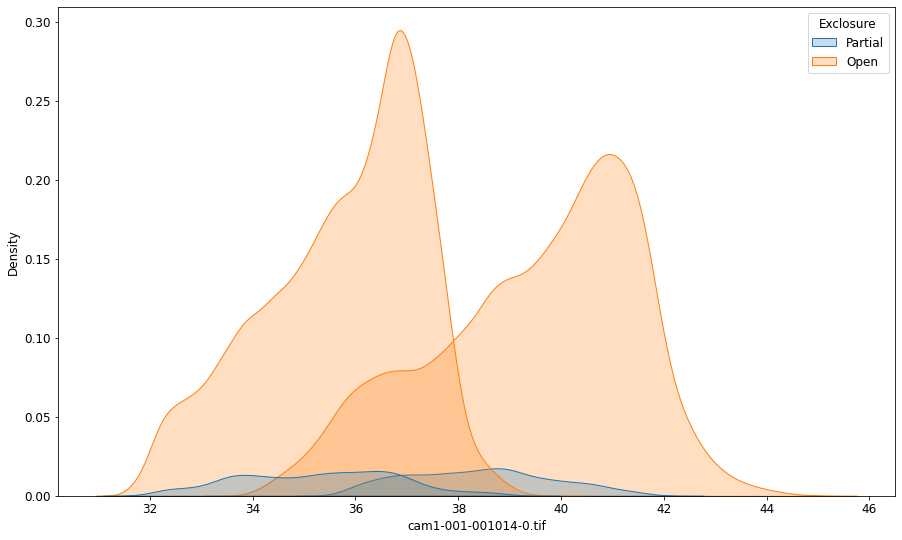

In [134]:
fig, ax = plt.subplots()
sns.kdeplot(data=df_img12, x=Path(i1).name, hue='Exclosure', ax=ax, fill=True)
sns.kdeplot(data=df_img12, x=Path(i2).name, hue='Exclosure', ax=ax, fill=True)

In [106]:
# Make a df from each
pix1_overlap_df = pix1_overlap.to_dataframe(name=Path(i1).name)
pix2_overlap_df = pix2_overlap.to_dataframe(name=Path(i2).name)

# Drop na rows
pix1_overlap_df.dropna(axis=0, inplace=True)
pix2_overlap_df.dropna(axis=0, inplace=True)

# Drop cols
pix1_overlap_df.drop(['band', 'spatial_ref'], axis=1, inplace=True)
pix2_overlap_df.drop(['band', 'spatial_ref'], axis=1, inplace=True)

pix12_overlap_df = pd.merge(pix1_overlap_df, pix2_overlap_df, on=['y', 'x'])

In [111]:
pix12_overlap_xr = pix12_overlap_df.to_xarray()

In [117]:
pix12_overlap_xr

<xarray.Dataset>
Dimensions:                (y: 370, x: 324)
Coordinates:
  * y                      (y) float64 7.372e+06 7.372e+06 ... 7.372e+06
  * x                      (x) float64 3.412e+05 3.412e+05 ... 3.413e+05
Data variables:
    cam1-001-001014-0.tif  (y, x) float32 nan nan nan nan ... nan nan nan nan
    cam1-001-000602-0.tif  (y, x) float32 nan nan nan nan ... nan nan nan nan

<AxesSubplot:title={'center':'band = 4, spatial_ref = 0'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>

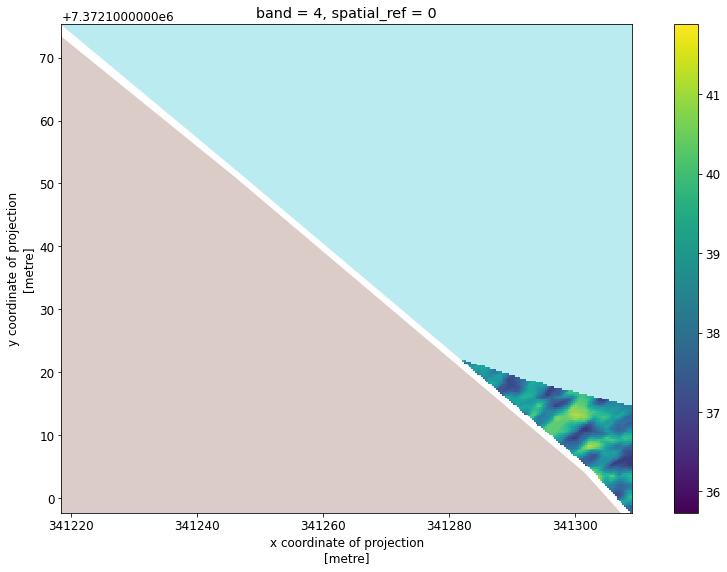

In [92]:
p = p_list[0]
p2 = p_list[1]
fig,ax = plt.subplots()
p.plot.pcolormesh(ax=ax)
# p2.plot.pcolormesh(ax=ax)
shp.plot('Exclosure', ax=ax, alpha=0.3)

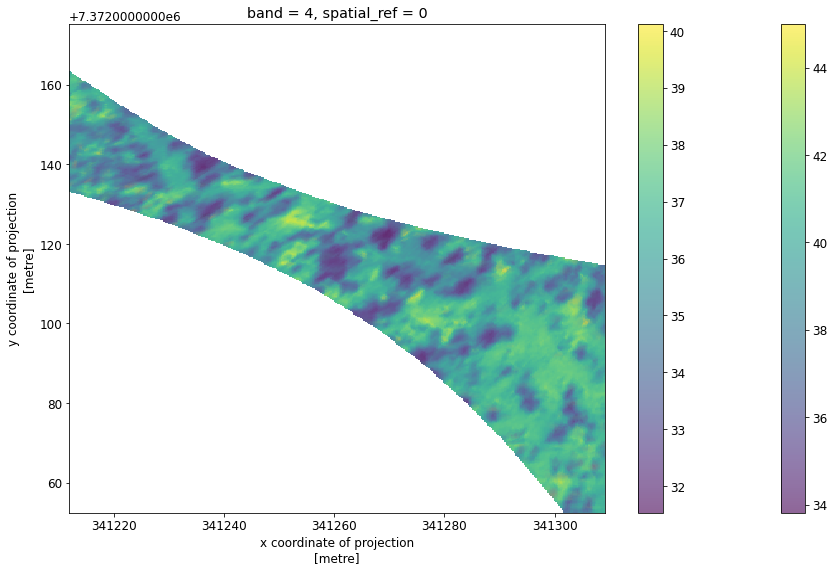

In [76]:
fig, ax = plt.subplots()
# pix1.where(np.isnan(diff, where=False), np.nan).plot.pcolormesh()
pix1_overlap.plot.pcolormesh(ax=ax, alpha=0.6)
pix2_overlap.plot.pcolormesh(ax=ax, alpha=0.6)

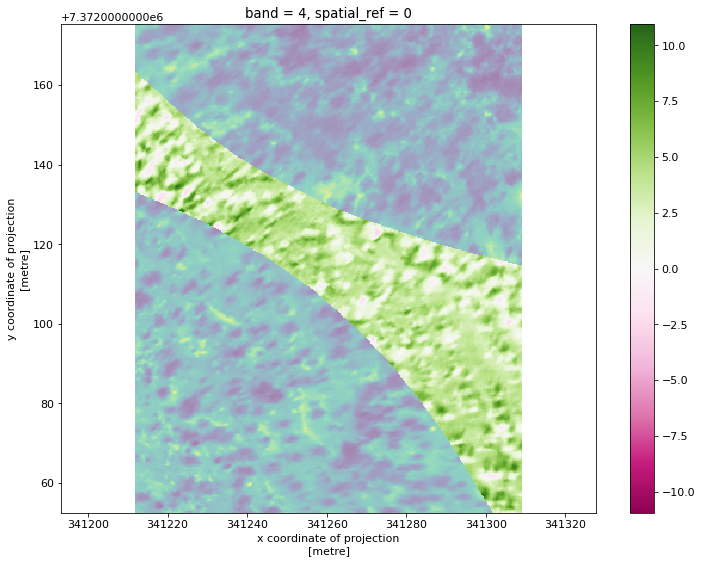

In [228]:
polygon = poly1.intersection(poly2[0])
fig, ax = plt.subplots()
# poly1.plot(ax=ax)
# poly2.plot(ax=ax, color='r')
pix1.plot.pcolormesh(ax=ax, alpha=0.5, add_colorbar=False)
pix2_match.plot.pcolormesh(ax=ax, alpha=0.5, add_colorbar=False)
# img1.sel(band=4).plot.pcolormesh(ax=ax, alpha=0.5)
# img2.sel(band=4).plot.pcolormesh(ax=ax, alpha=0.5)
# polygon.plot(ax=ax, color='c', alpha=0.3)
diff.plot.pcolormesh(ax=ax, alpha=1, cmap='PiYG')
ax.axis('equal')
fig.savefig(f'./figs/ImageDifferenceFigures/{projstr}/TempDiff_{projstr}_cam1-001-001014-0_cam1-001-000602-0.tif', dpi=300)